# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Isa Prins | 6578977 |
| Arjun avhale | 6542786 |
| Thijs Spilt | 6540619 |

In [14]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Isa', 'Thijs','Arjun']

## Opdracht 1: Planning.

| Planning Groep: 22     |Tijdstip / Tijdspanne  |
|---|---|
| Meetopstelling getest | 12:00 |
| iteratie 0 af | 14:00 |
| Algoritme werkt, klaar | 16:00 |
| groep aanwezig 1| 13:30 |
| groep aanwezig 2| 16:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:15-16:30 |

## Opdracht 2: Import libs.

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [22]
<img src="IMG_8416.jpg" width="400">

0.034259072918762845
0.15852284161825692


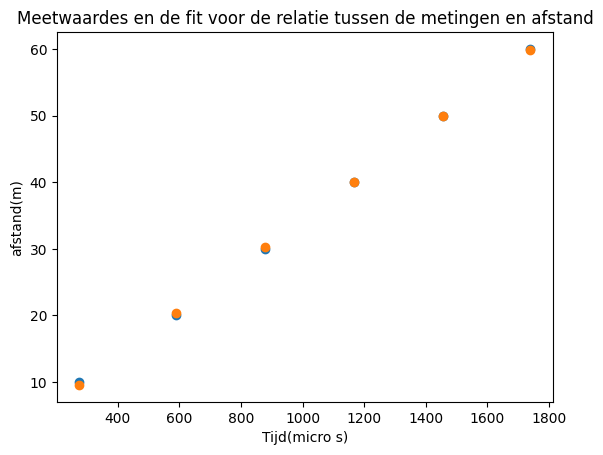

In [40]:
metingen = np.array([275,588,878,1166,1455,1740])
afstanden = np.array([10,20,30,40,50,60])

def FitFunc(x,a,b):
    return (a*x) +b

values, cov = curve_fit(FitFunc,metingen,afstanden)

plt.ylabel('afstand(m)')
plt.xlabel('Tijd(micro s)')
plt.scatter(metingen,afstanden,label = 'Metingen')
plt.scatter(metingen, FitFunc(metingen,values[0],values[1]),label = 'Fit: y = 0.034*x + 0.1585')
plt.legend
plt.title('Meetwaardes en de fit voor de relatie tussen de metingen en afstand')

print(values[0])
print(values[1])

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  40.5
1   0  30   0  20  39.8
2  40   0  30   0  40.2
3  30   0  20   0  39.4


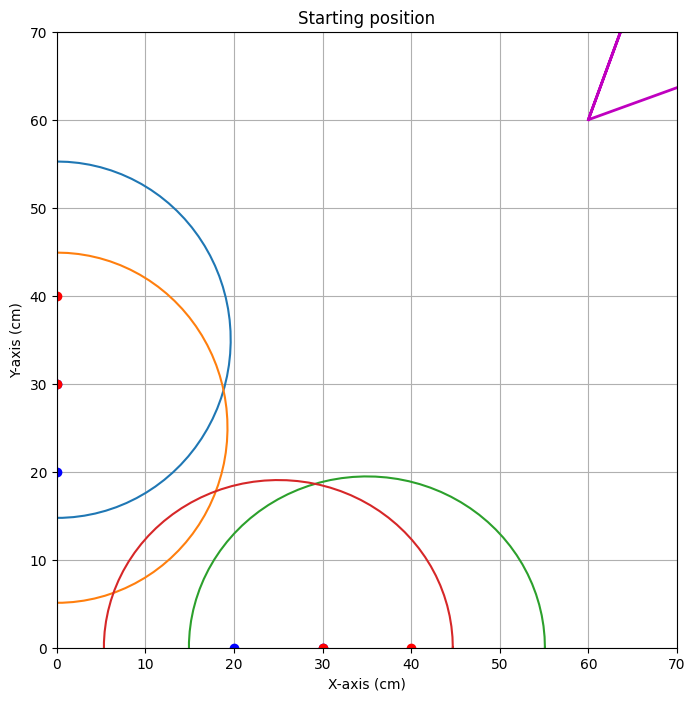


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.980


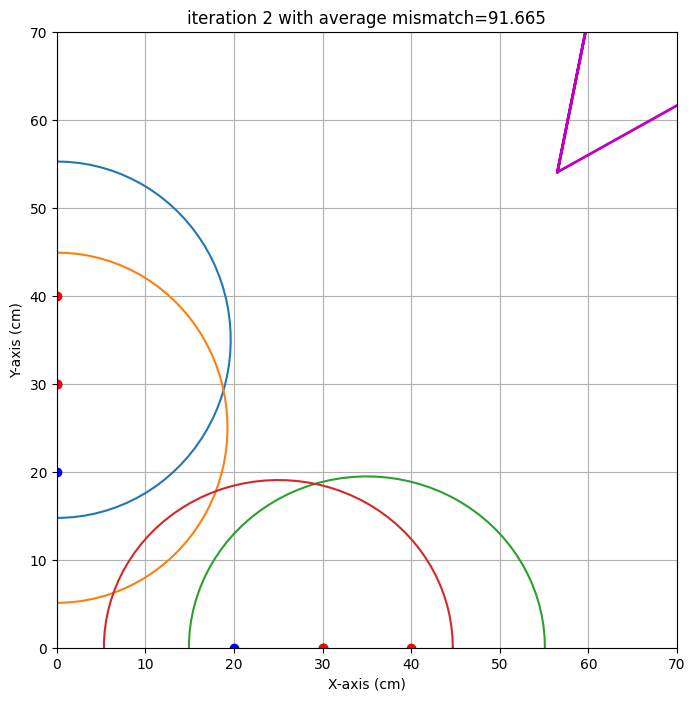

end iteration 2 with average mismatch=91.665


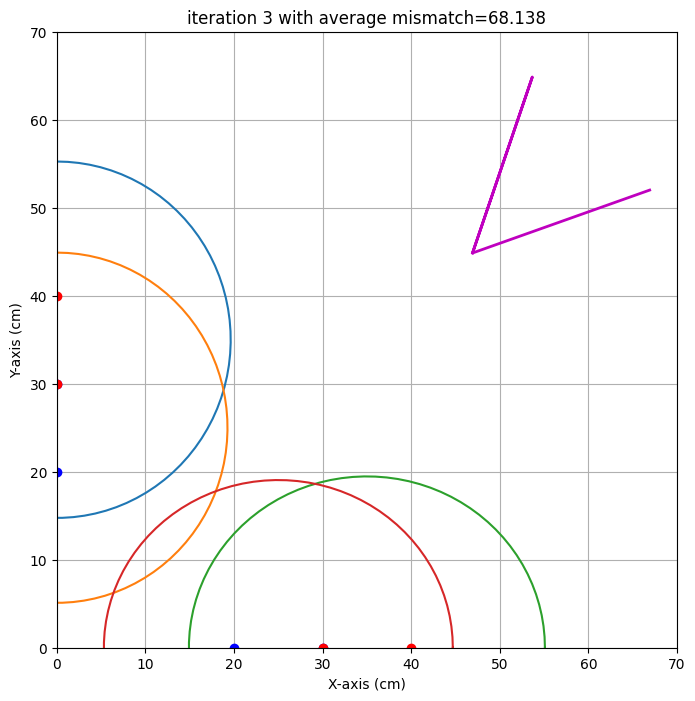

end iteration 3 with average mismatch=68.138


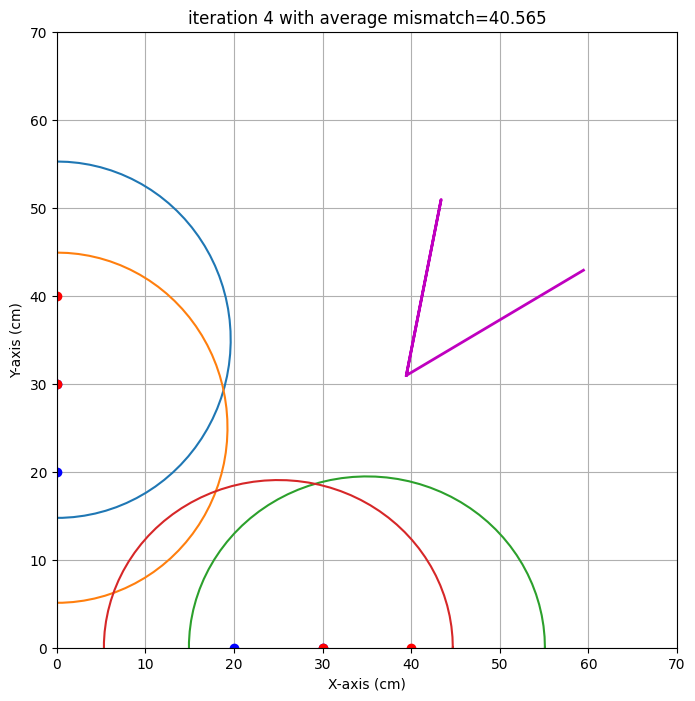

end iteration 4 with average mismatch=40.565


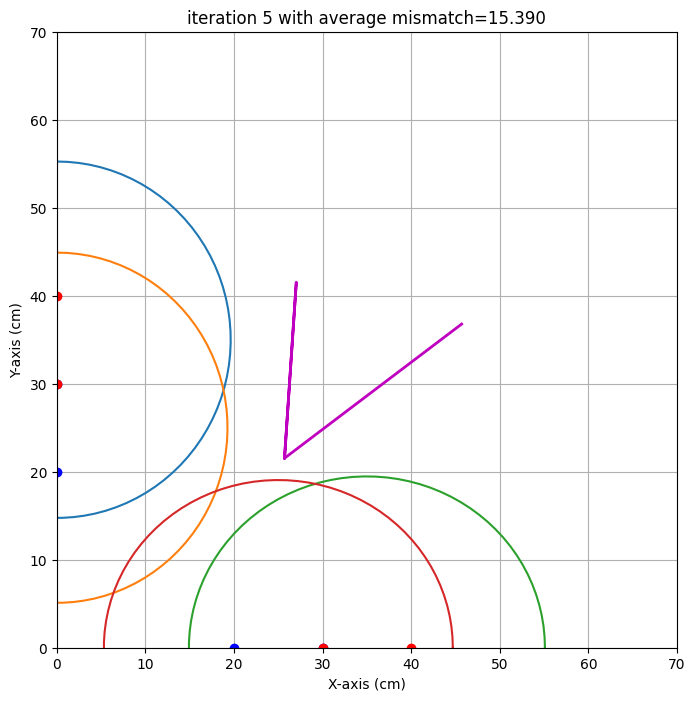

end iteration 5 with average mismatch=15.390


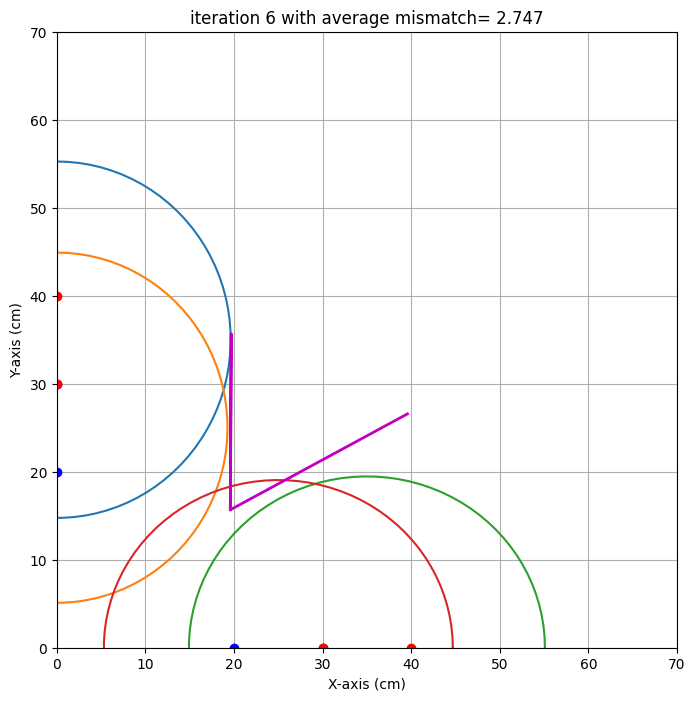

end iteration 6 with average mismatch= 2.747
end iteration 7 with average mismatch= 2.596


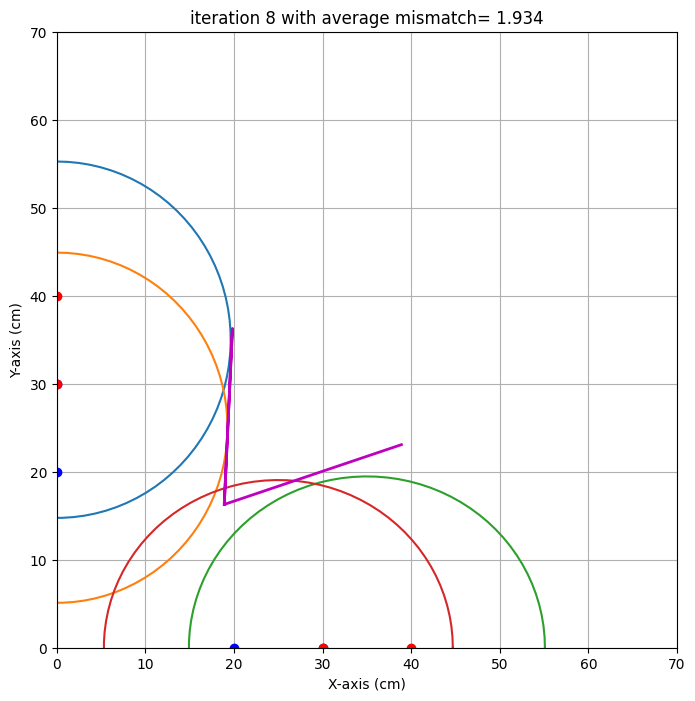

end iteration 8 with average mismatch= 1.934


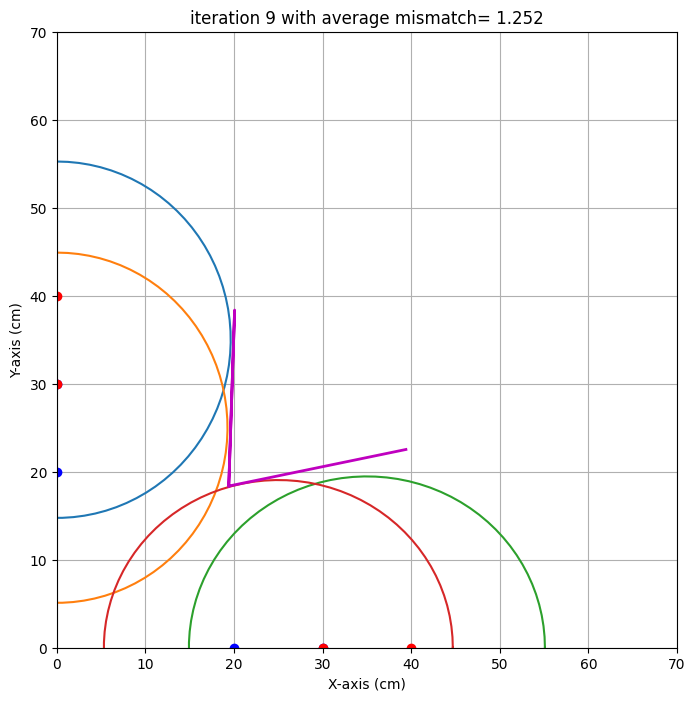

end iteration 9 with average mismatch= 1.252


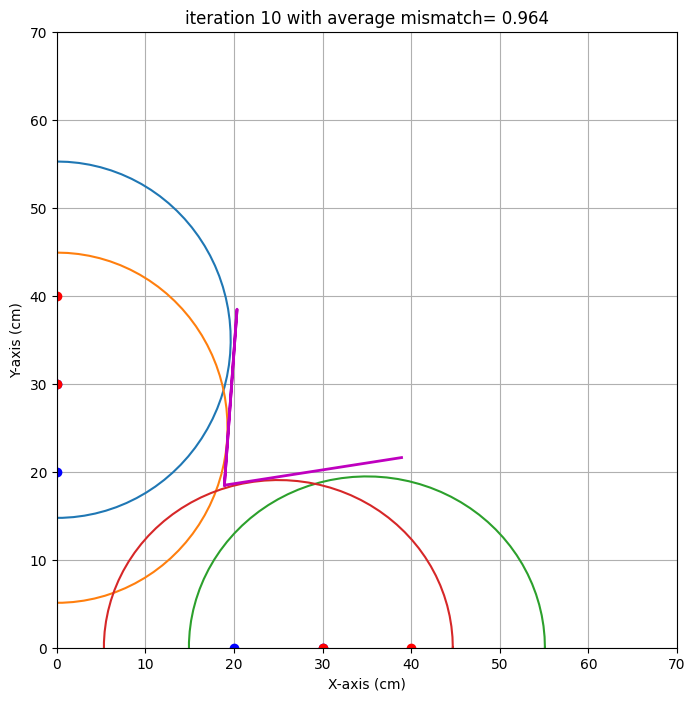

end iteration 10 with average mismatch= 0.964


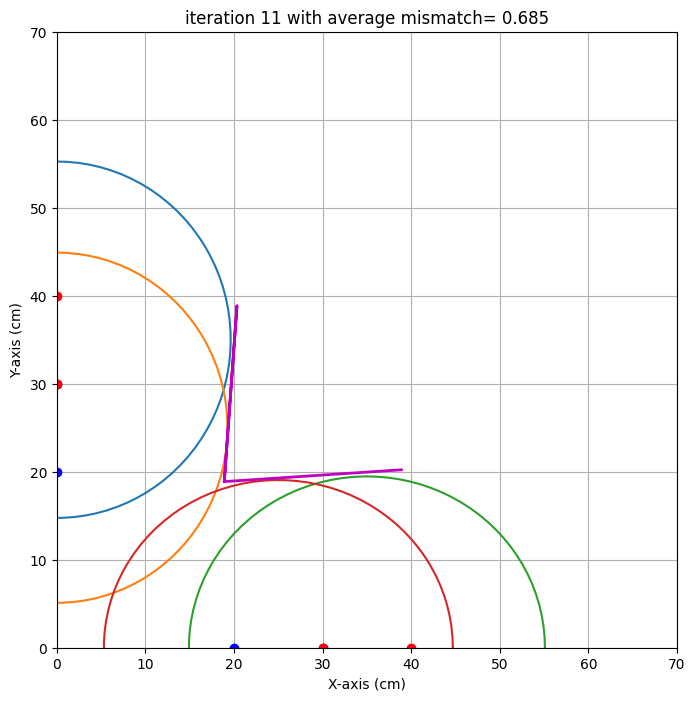

end iteration 11 with average mismatch= 0.685


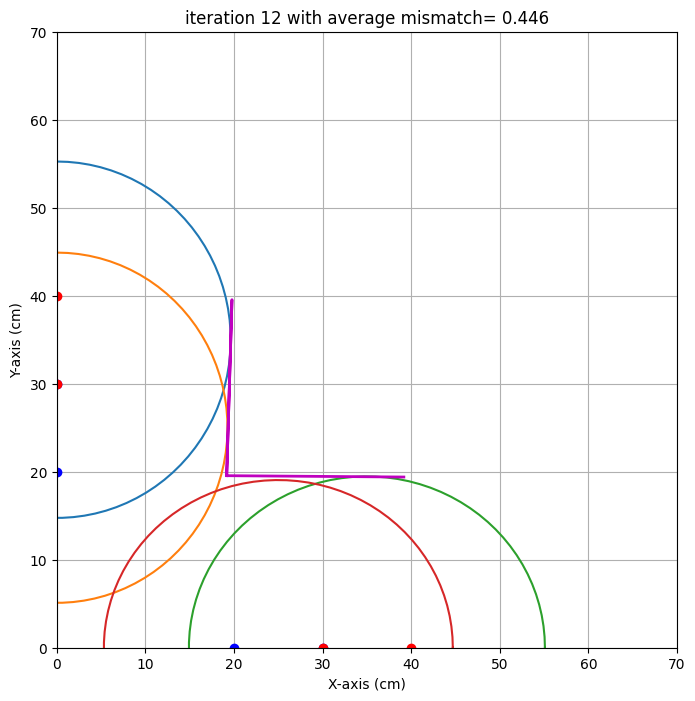

end iteration 12 with average mismatch= 0.446
end iteration 13 with average mismatch= 0.445


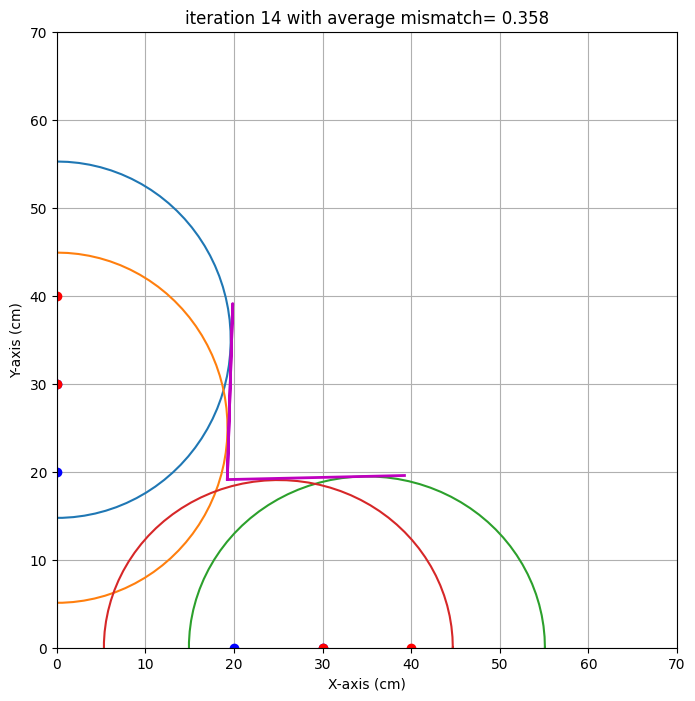

end iteration 14 with average mismatch= 0.358


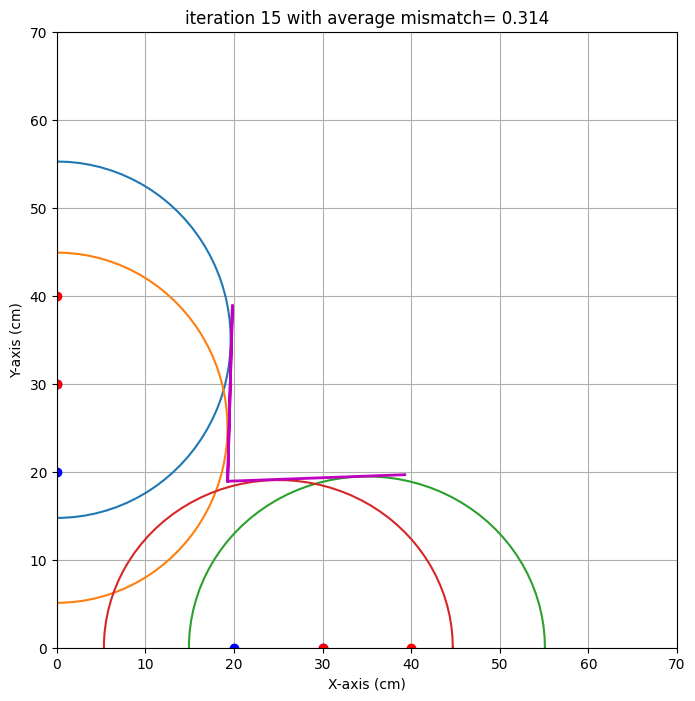

end iteration 15 with average mismatch= 0.314


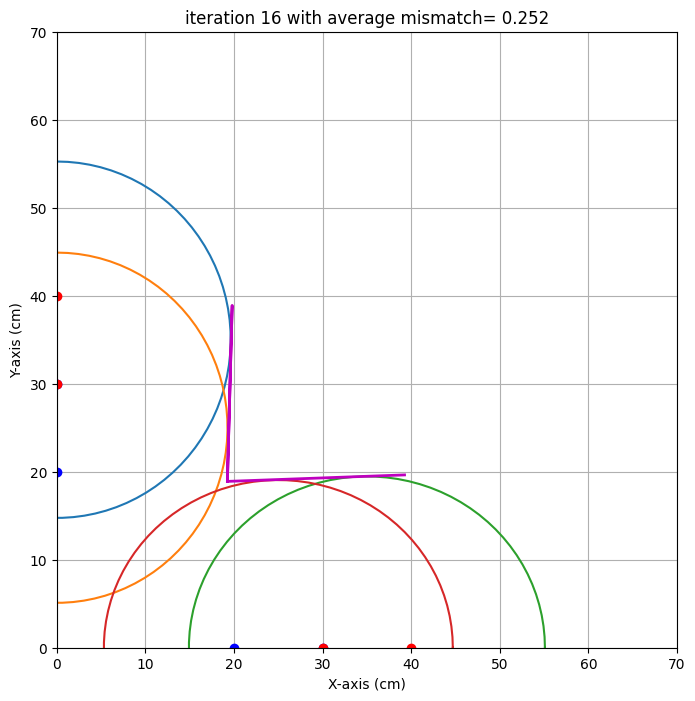

end iteration 16 with average mismatch= 0.252
end iteration 17 with average mismatch= 0.243
end iteration 18 with average mismatch= 0.236


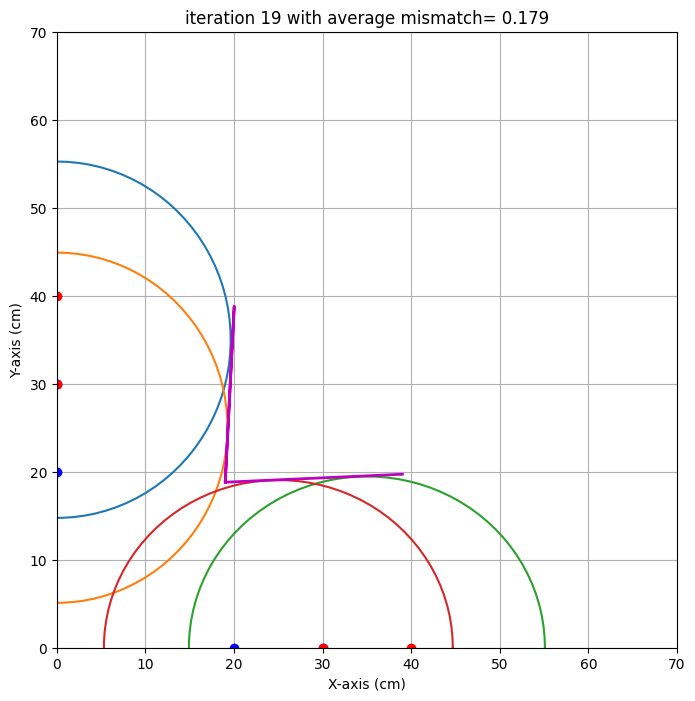

end iteration 19 with average mismatch= 0.179
end iteration 20 with average mismatch= 0.170
end iteration 21 with average mismatch= 0.168
end iteration 22 with average mismatch= 0.168
end iteration 23 with average mismatch= 0.168
end iteration 24 with average mismatch= 0.167
end iteration 25 with average mismatch= 0.167
end iteration 26 with average mismatch= 0.167
end iteration 27 with average mismatch= 0.167
end iteration 28 with average mismatch= 0.167
end iteration 29 with average mismatch= 0.167
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.167
###############################################################################
end of iteration  30
Best alpha=   2.59 with uncertainty=   0.57
Best beta =   2.90 with uncertainty=   0.98
Best x0   =  18.98 with uncertainty=   0.40
Best y0   =  18.79 with uncertainty=   0.22
##############################################################

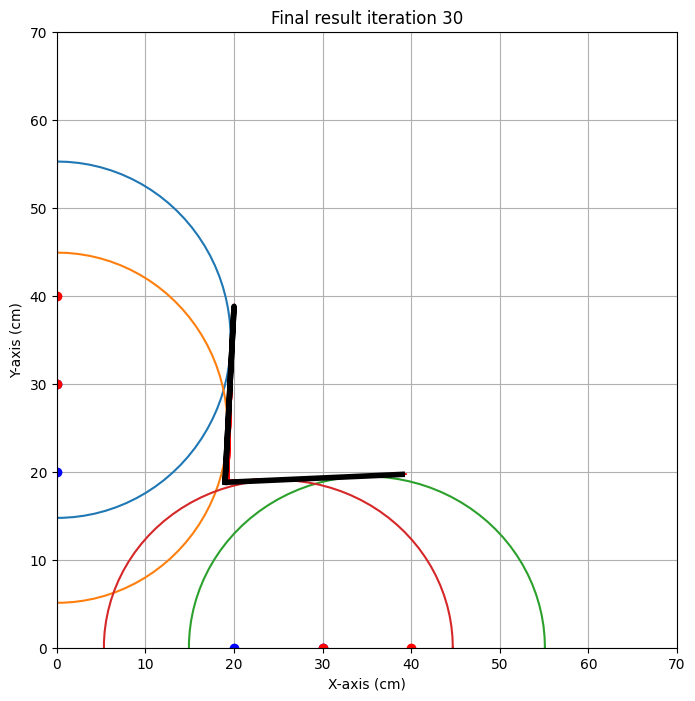

In [12]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,39.8],
    #[0,10,0,20,0], ongeldig
    [40,0,30,0,40.2],
    [30,0,20,0,39.4],
    #[10,0,20,0,0], ongeldig
    #[10,0,0,10,0] ongeldig   
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [13]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.0 cm met een standaardafwijking van 0.4 cm 
y0: 18.8 cm met een standaardafwijking van 0.2 cm 
alpha: 2.6 graden met een standaardafwijking van 0.6 graad 
beta: 2.9 graden met een standaardafwijking van 1.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Isa]

<img src="Schema1.jpeg" width="400">

#### algoritme [Arjun]

<img src="Schema2.jpeg" width="400">

#### algoritme [Thijs]

<img src="Schema3.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 35,  #zelf aanvullen,
           'y0': 43.5, #zelf aanvullen,
           'alpha' : 3, #zelf aanvullen,
           'beta' : 26, #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.


data ={'Thijs' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,40,0,90],
    [40,0,50,0,89],
    [0,60,0,70,87],
    [35,0,45,0,87],
    [0,55,0,65,86],
    ]),
       'Isa' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,30,0,76],
    [45,0,30,0,78],
    [0,70,0,55,85],
    ]),
    'Arjun' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,30,0,76],
    [45,0,30,0,78],
    [0,70,0,55,85],
    ])
      }

#Arjun en Isa hebben dezelfde metingen omdat we maar twee metingen hadden gedaan maar de code breekt als je niet alle drie de personen
#in de code hebt dus dit is de oplossing :)

## Opdracht 7: Evaluatie.

Isa
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  40   0  30   0  76
1  45   0  30   0  78
2   0  70   0  55  85


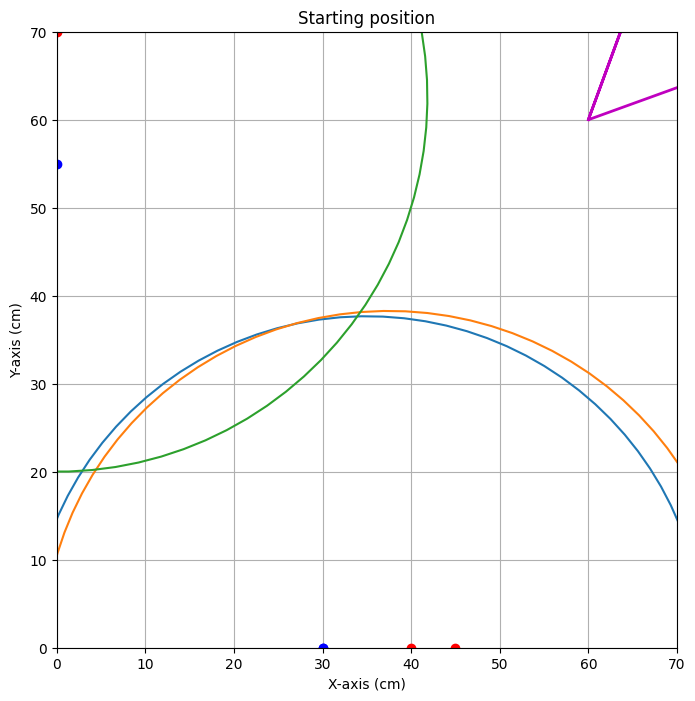


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.536


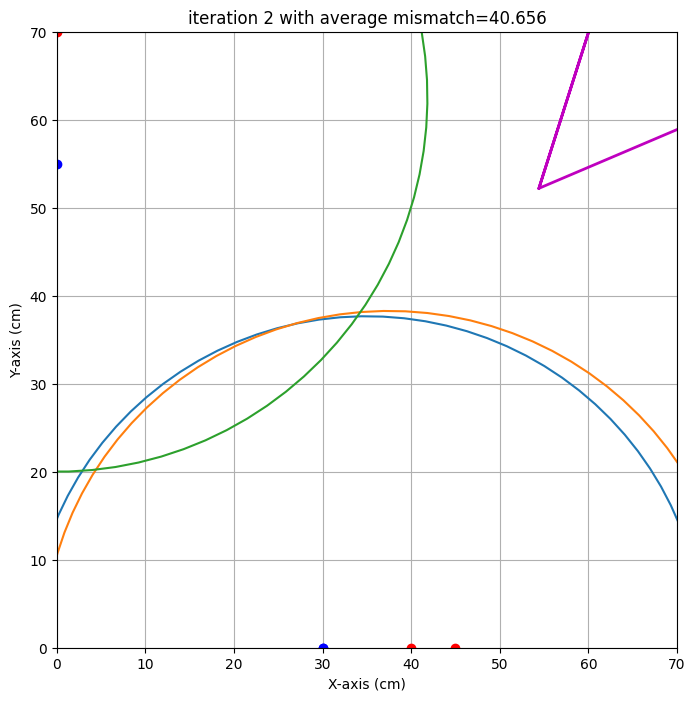

end iteration 2 with average mismatch=40.656


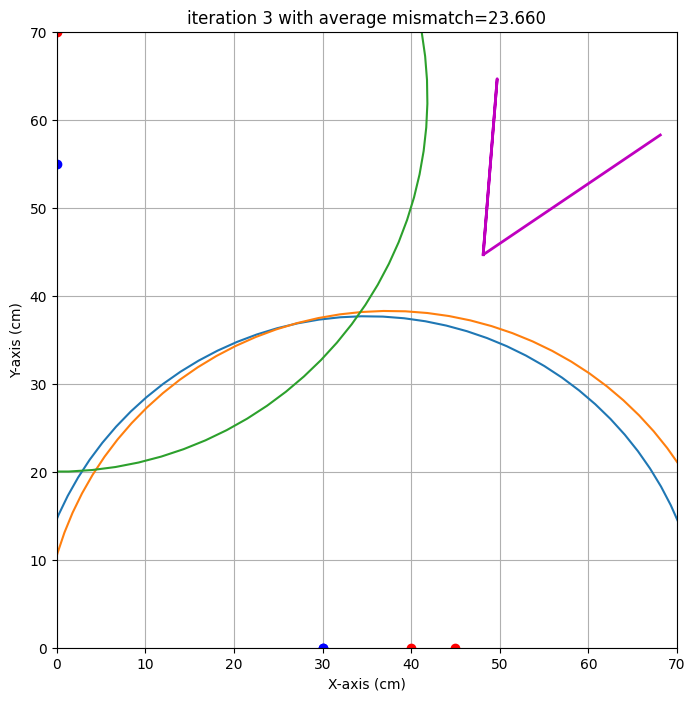

end iteration 3 with average mismatch=23.660


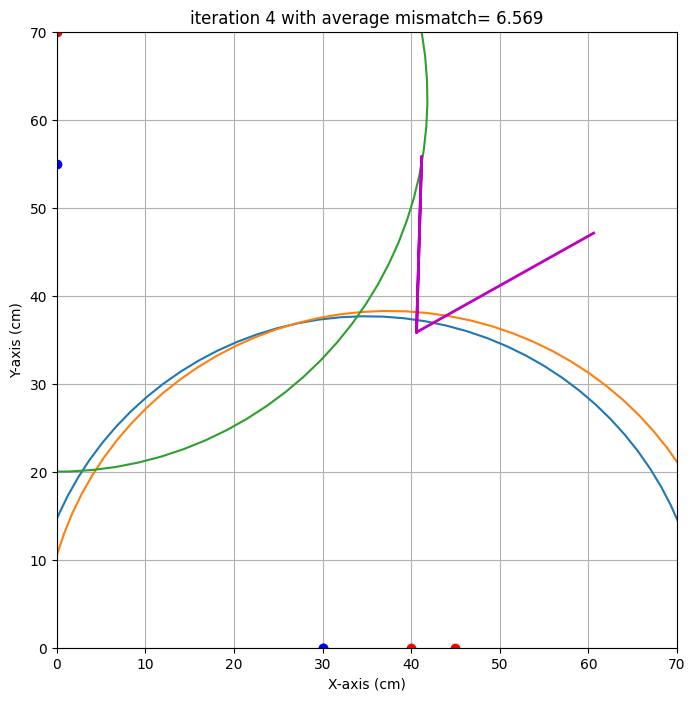

end iteration 4 with average mismatch= 6.569


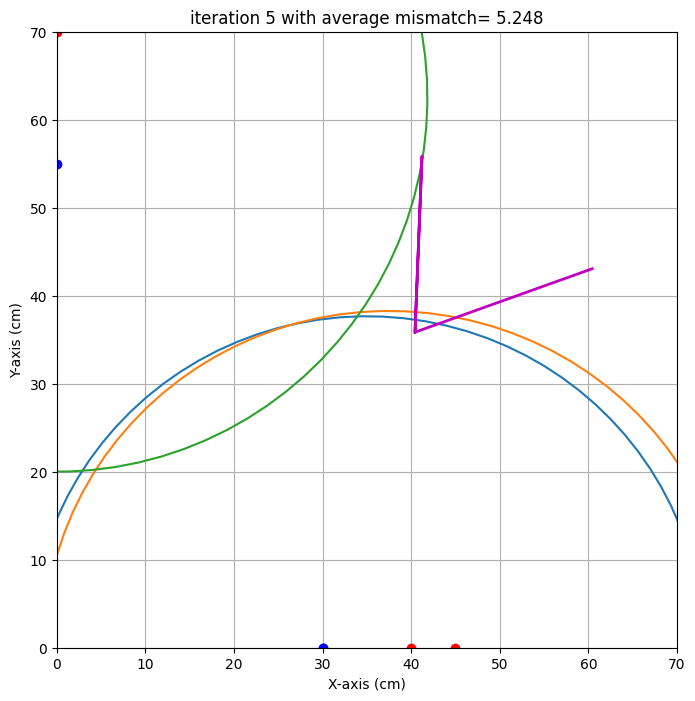

end iteration 5 with average mismatch= 5.248


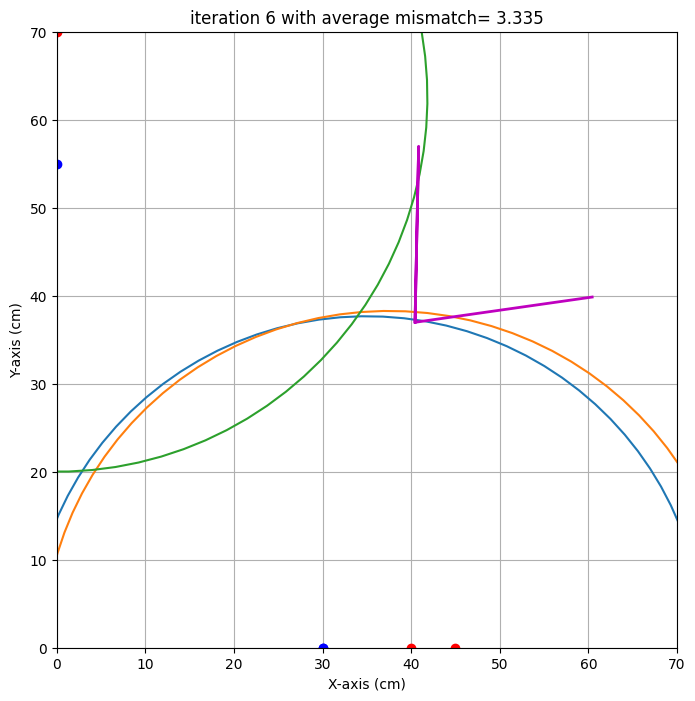

end iteration 6 with average mismatch= 3.335


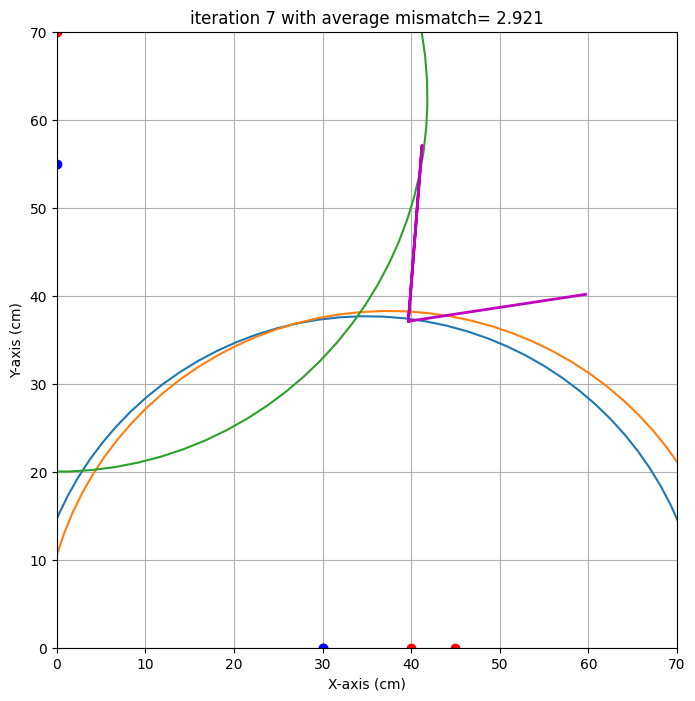

end iteration 7 with average mismatch= 2.921
end iteration 8 with average mismatch= 2.921


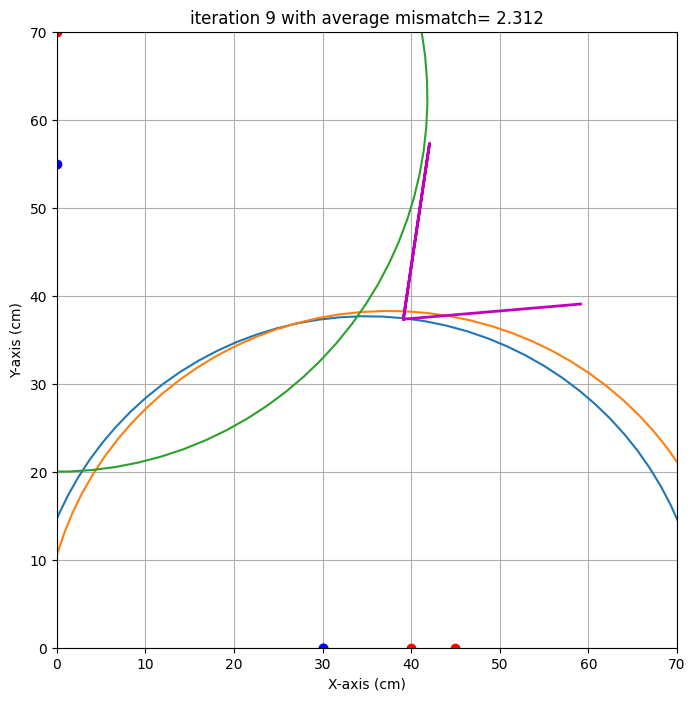

end iteration 9 with average mismatch= 2.312


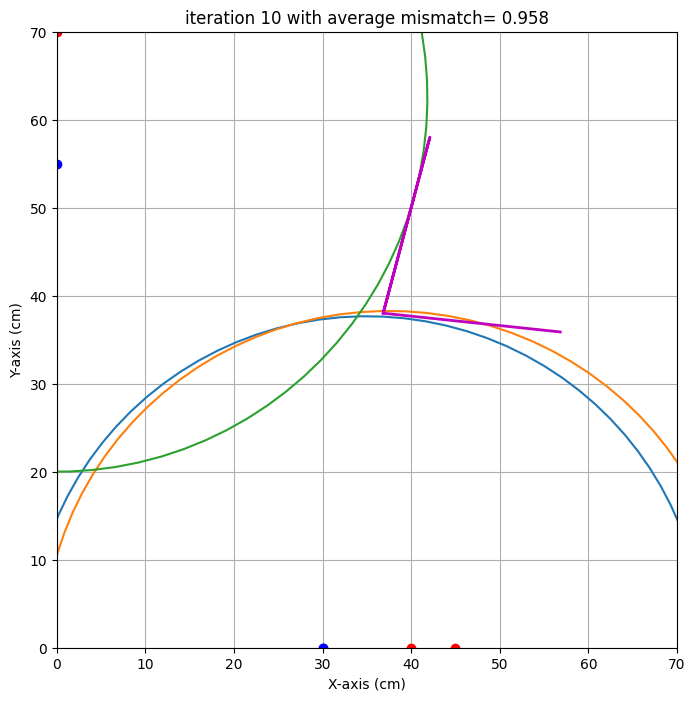

end iteration 10 with average mismatch= 0.958


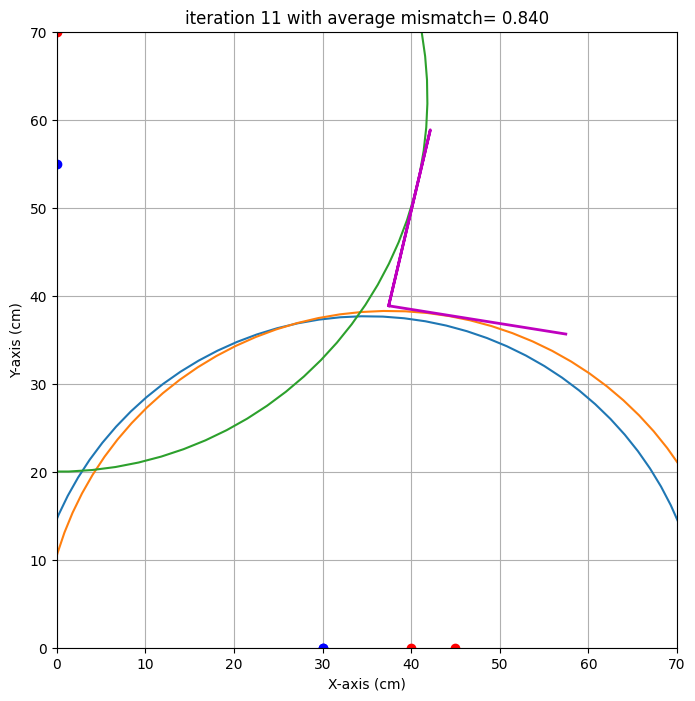

end iteration 11 with average mismatch= 0.840


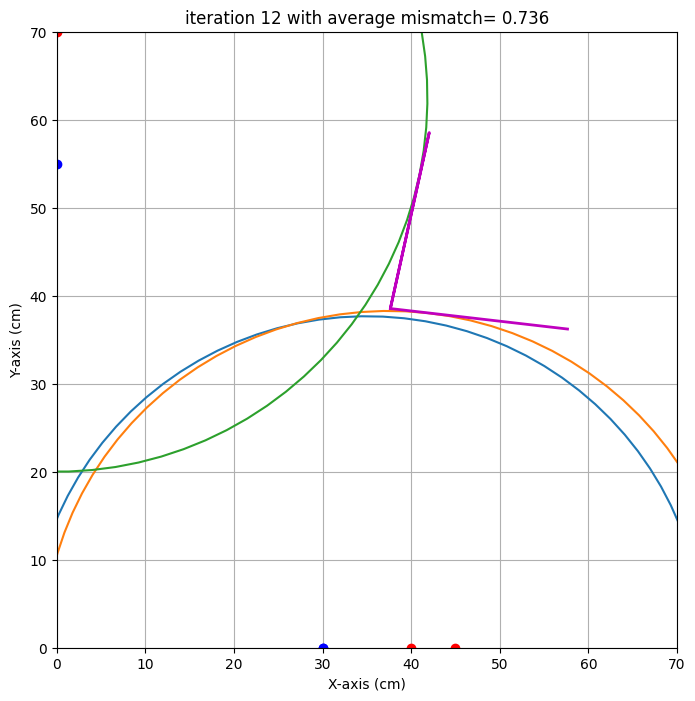

end iteration 12 with average mismatch= 0.736
end iteration 13 with average mismatch= 0.702
end iteration 14 with average mismatch= 0.701
end iteration 15 with average mismatch= 0.699


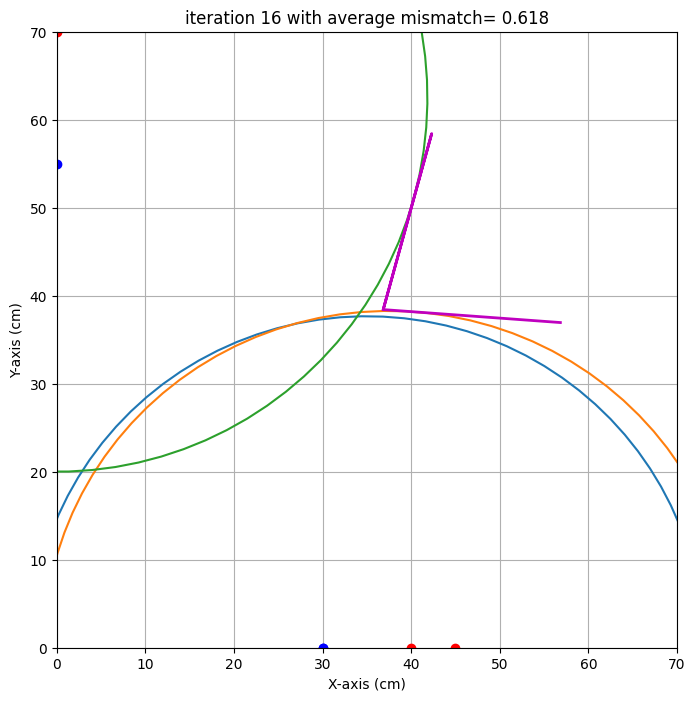

end iteration 16 with average mismatch= 0.618
end iteration 17 with average mismatch= 0.616
end iteration 18 with average mismatch= 0.616
end iteration 19 with average mismatch= 0.616
end iteration 20 with average mismatch= 0.616
end iteration 21 with average mismatch= 0.616
end iteration 22 with average mismatch= 0.616
end iteration 23 with average mismatch= 0.616
end iteration 24 with average mismatch= 0.616
end iteration 25 with average mismatch= 0.616
end iteration 26 with average mismatch= 0.616
end iteration 27 with average mismatch= 0.616
end iteration 28 with average mismatch= 0.616
end iteration 29 with average mismatch= 0.616
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.616
###############################################################################
end of iteration  30
Best alpha=  -4.21 with uncertainty=   4.24
Best beta =  15.31 with uncertainty=  11.22
Best x0   = 

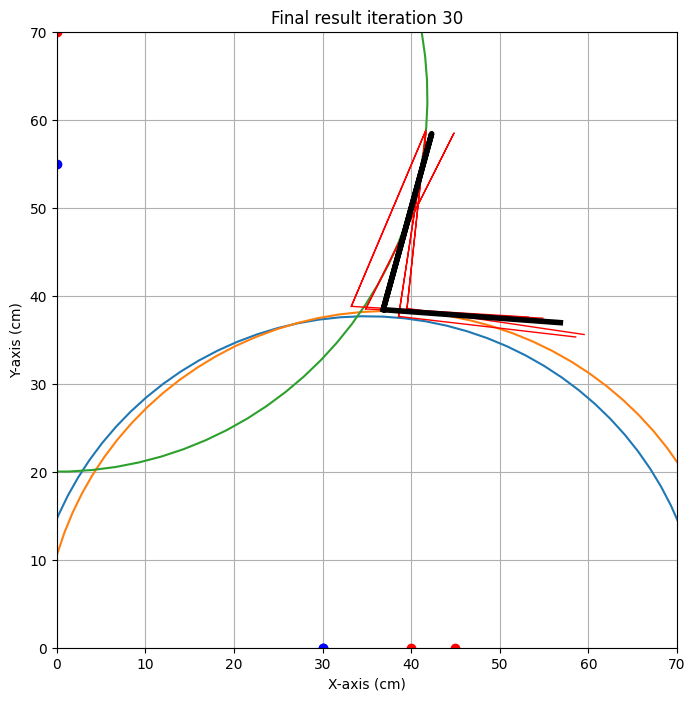

{'alpha': np.float64(-4.2117502669812605), 'alpha_eps': np.float64(4.237490991067721), 'beta': np.float64(15.305544823643233), 'beta_eps': np.float64(11.218479947746046), 'x0': np.float64(36.837972316132706), 'x0_eps': np.float64(3.600016963393614), 'y0': np.float64(38.41347949872185), 'y0_eps': np.float64(0.7663707573367589)}
Thijs
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  30   0  40   0  90
1  40   0  50   0  89
2   0  60   0  70  87
3  35   0  45   0  87
4   0  55   0  65  86


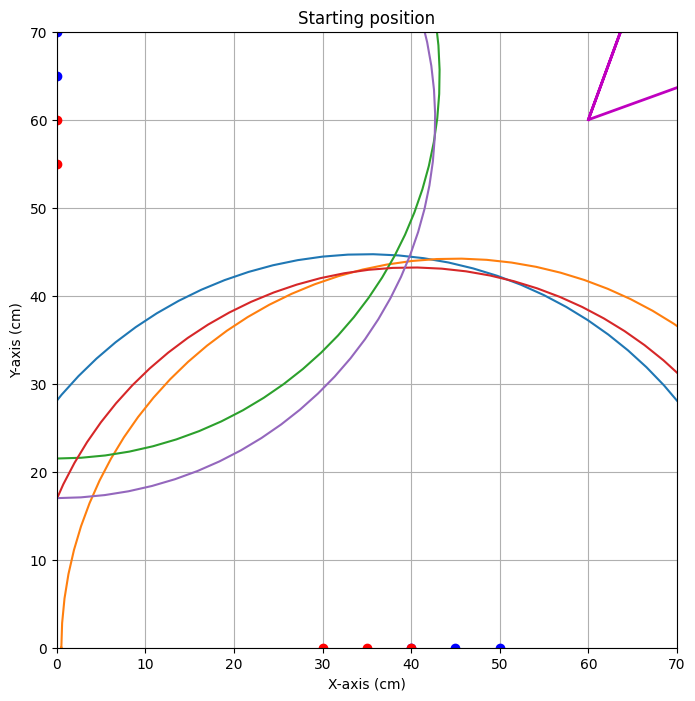


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.662


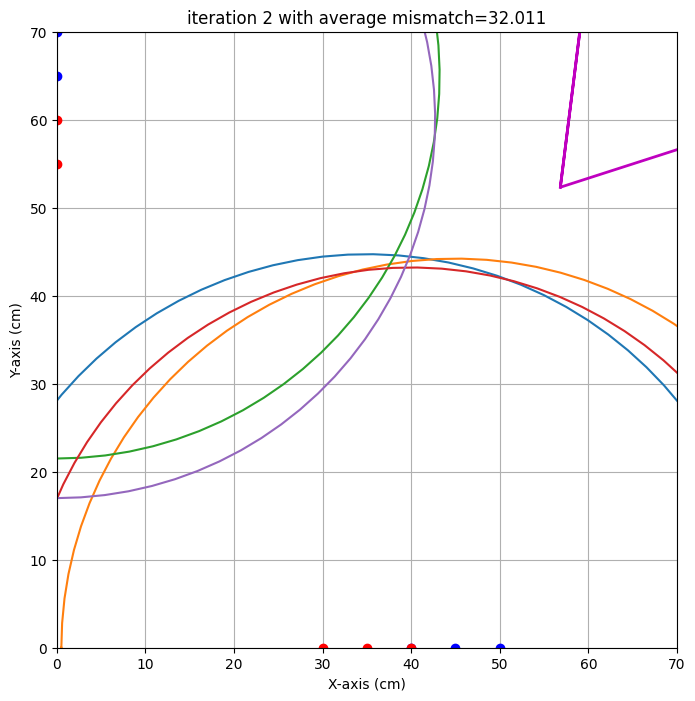

end iteration 2 with average mismatch=32.011


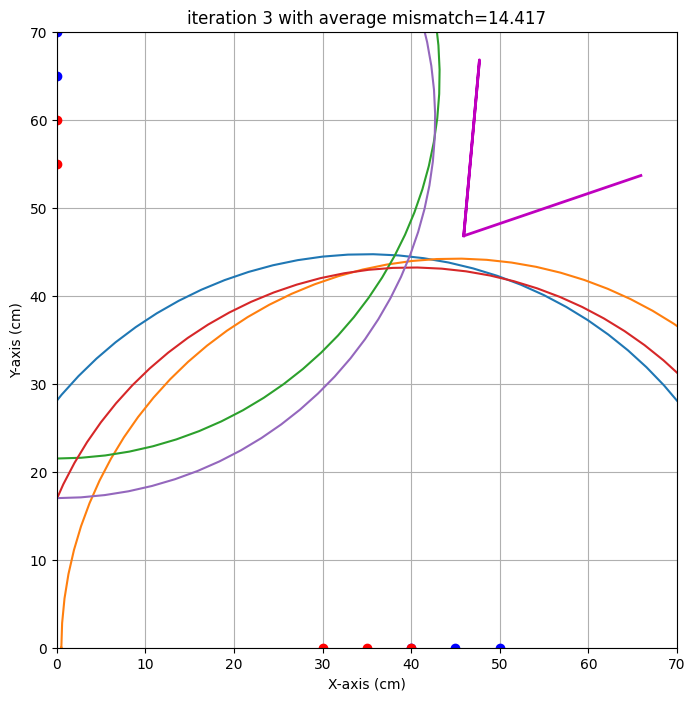

end iteration 3 with average mismatch=14.417


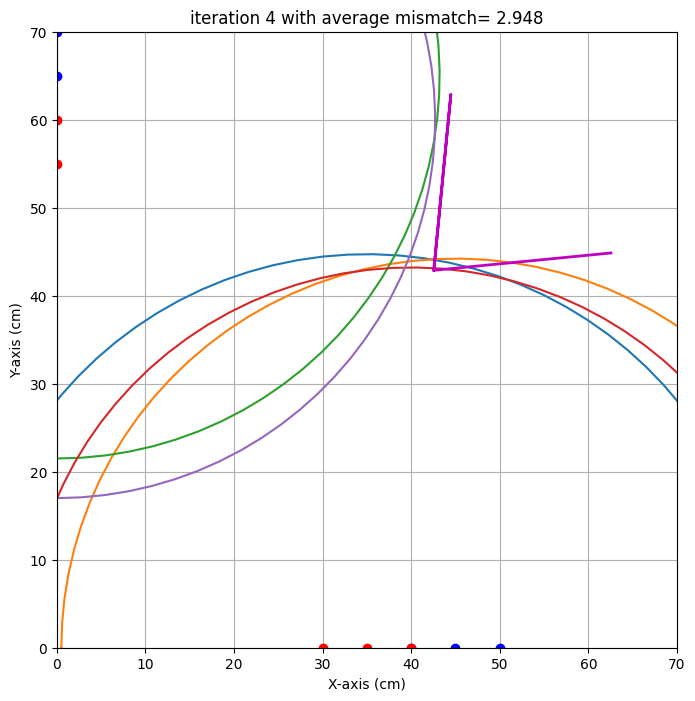

end iteration 4 with average mismatch= 2.948


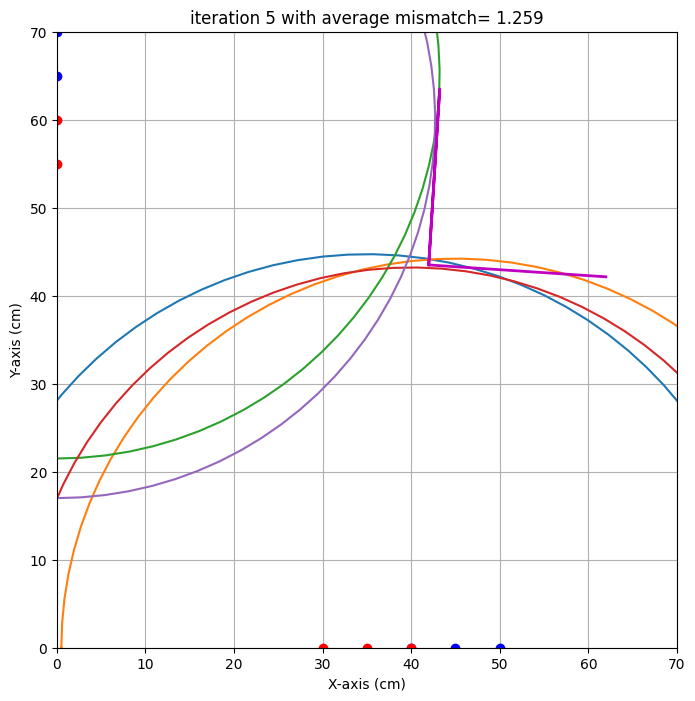

end iteration 5 with average mismatch= 1.259
end iteration 6 with average mismatch= 1.246


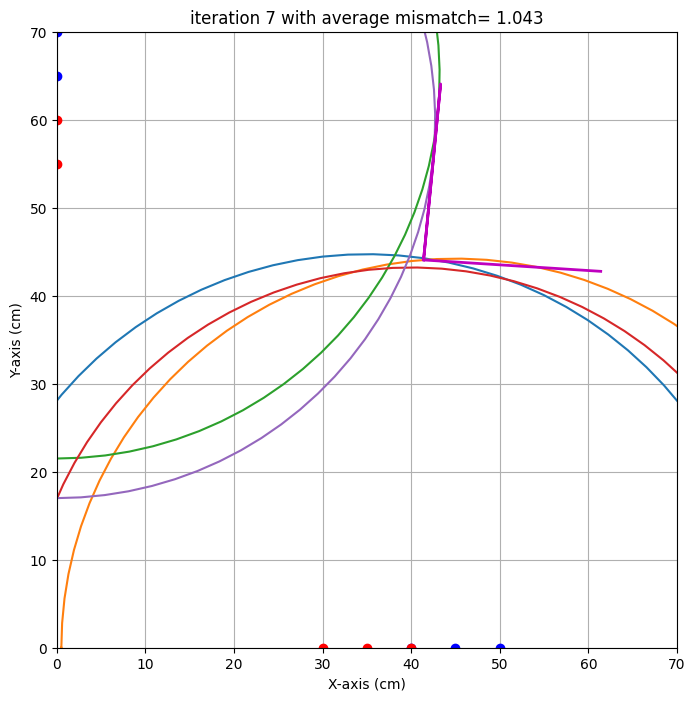

end iteration 7 with average mismatch= 1.043
end iteration 8 with average mismatch= 1.042
end iteration 9 with average mismatch= 1.042
end iteration 10 with average mismatch= 1.042
end iteration 11 with average mismatch= 1.042
end iteration 12 with average mismatch= 1.042
end iteration 13 with average mismatch= 1.042
end iteration 14 with average mismatch= 1.042
end iteration 15 with average mismatch= 1.042
end iteration 16 with average mismatch= 1.042
end iteration 17 with average mismatch= 1.042
end iteration 18 with average mismatch= 1.042
end iteration 19 with average mismatch= 1.042
end iteration 20 with average mismatch= 1.033
end iteration 21 with average mismatch= 1.029
end iteration 22 with average mismatch= 1.020
end iteration 23 with average mismatch= 1.012
end iteration 24 with average mismatch= 1.012
end iteration 25 with average mismatch= 1.012
end iteration 26 with average mismatch= 0.985
end iteration 27 with average mismatch= 0.985
end iteration 28 with average mismatc

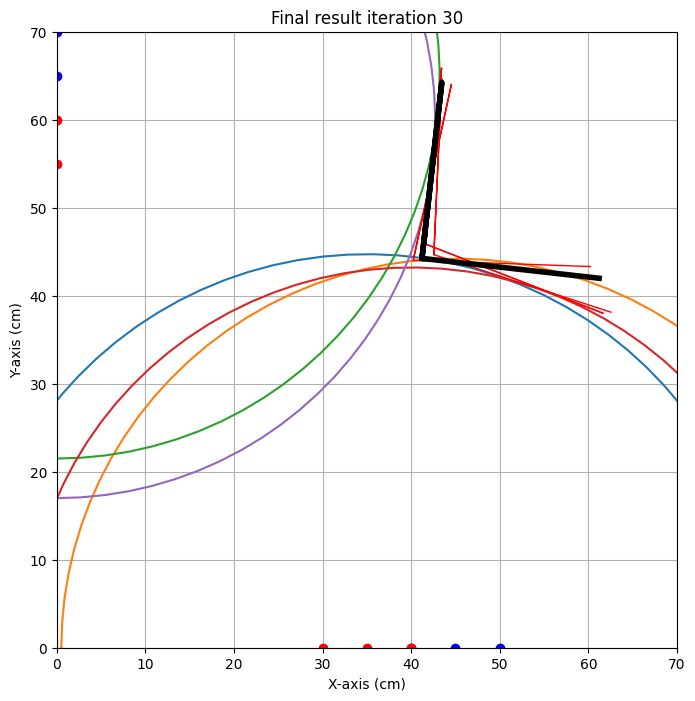

{'alpha': np.float64(-6.428291309438002), 'alpha_eps': np.float64(14.986436538331859), 'beta': np.float64(6.392621527117783), 'beta_eps': np.float64(5.780926105518366), 'x0': np.float64(41.21669086609907), 'x0_eps': np.float64(1.3412271516658265), 'y0': np.float64(44.2403251739408), 'y0_eps': np.float64(1.6147914399951446)}
Arjun
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  40   0  30   0  76
1  45   0  30   0  78
2   0  70   0  55  85


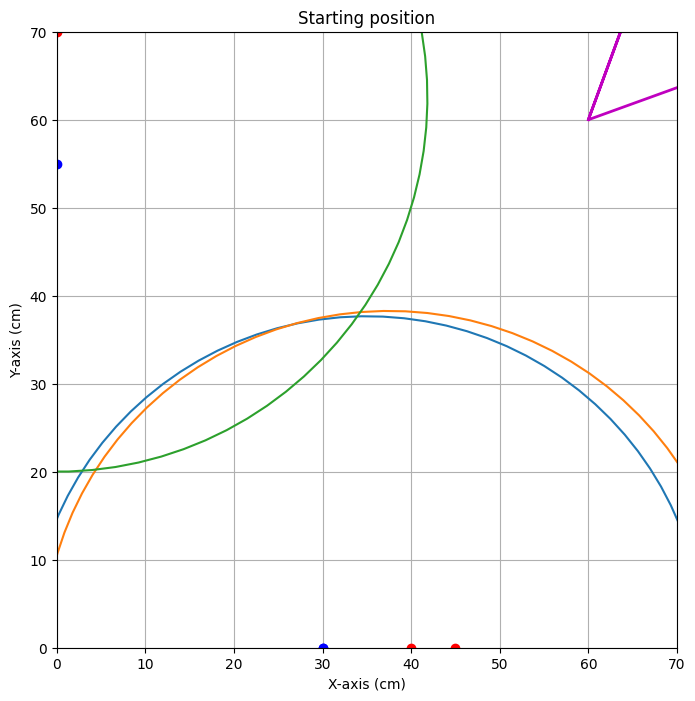


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=53.536


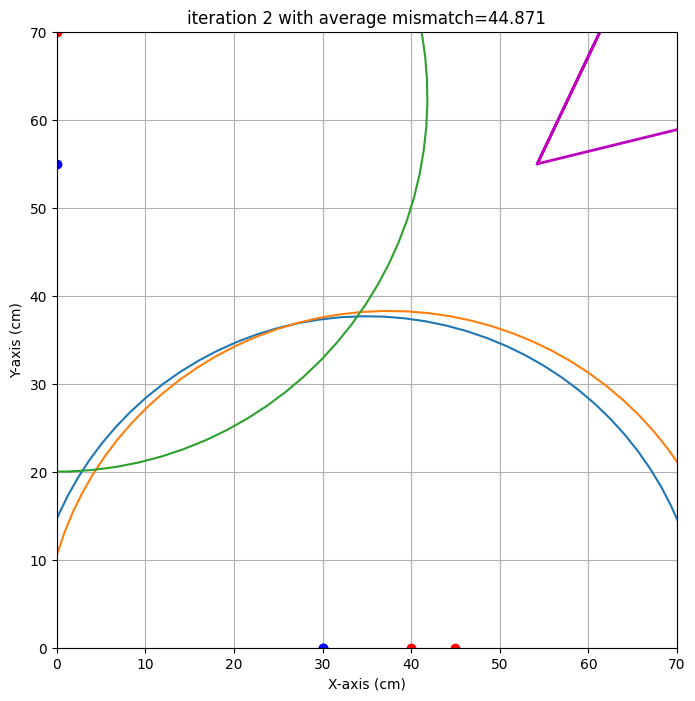

end iteration 2 with average mismatch=44.871


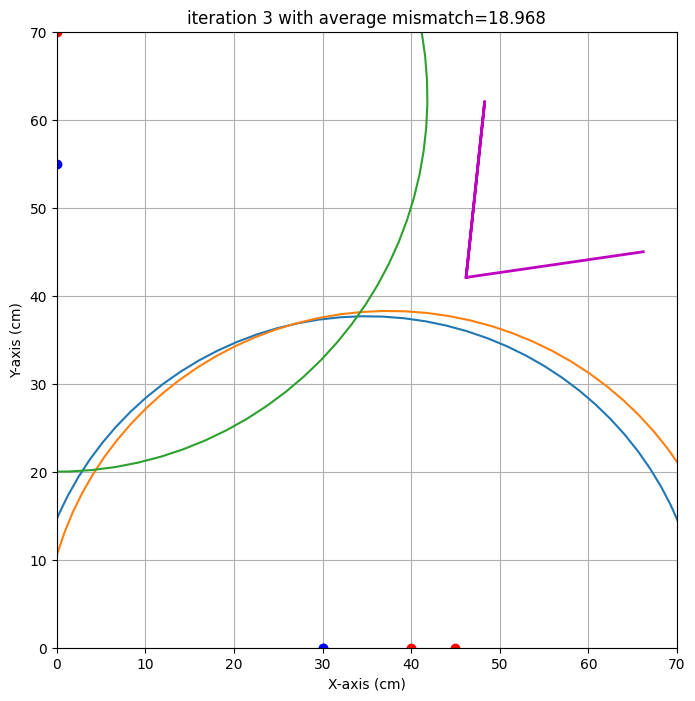

end iteration 3 with average mismatch=18.968


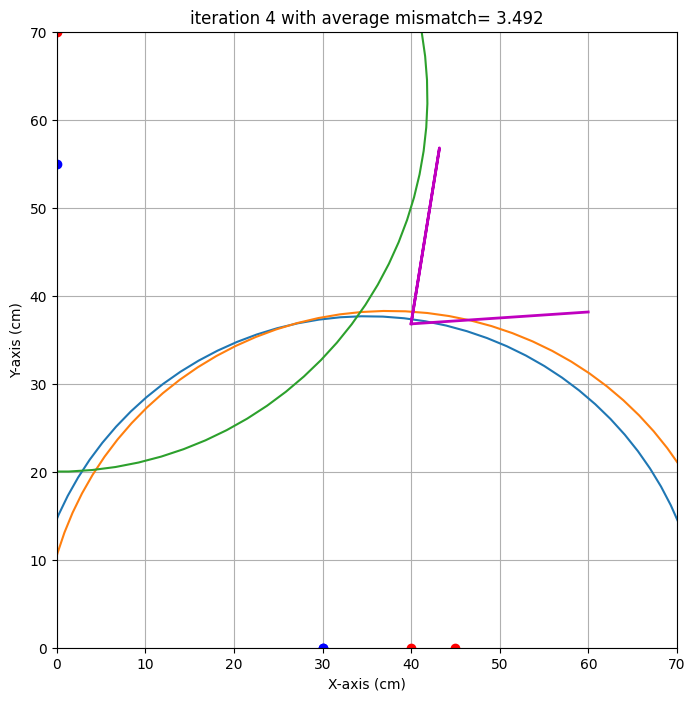

end iteration 4 with average mismatch= 3.492


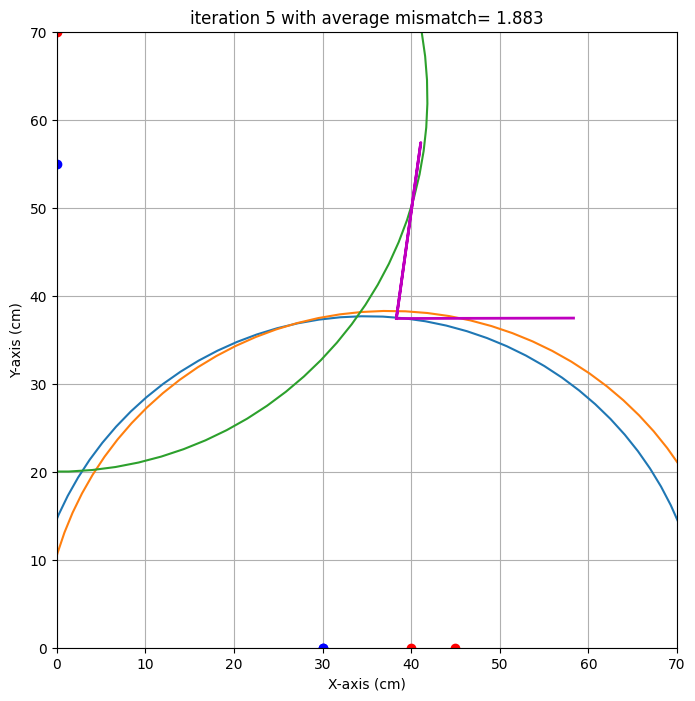

end iteration 5 with average mismatch= 1.883


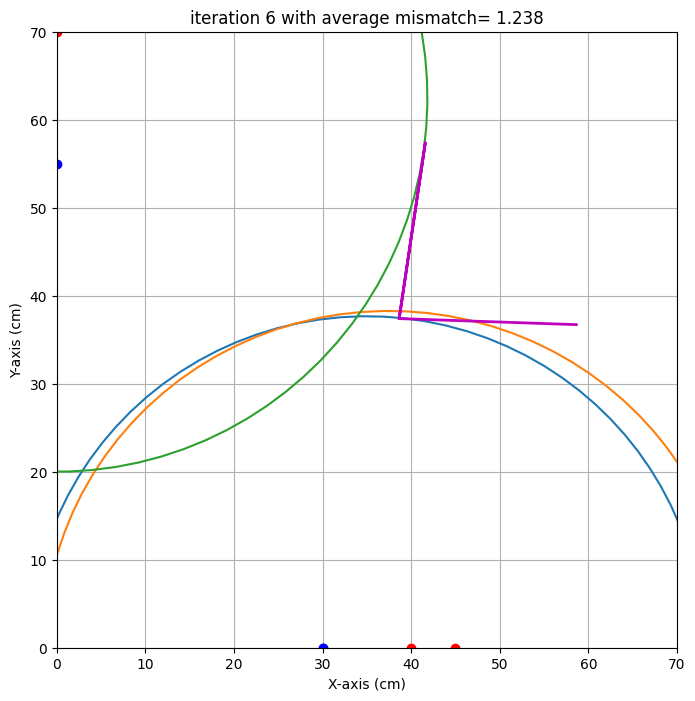

end iteration 6 with average mismatch= 1.238
end iteration 7 with average mismatch= 1.238
end iteration 8 with average mismatch= 1.186
end iteration 9 with average mismatch= 1.117


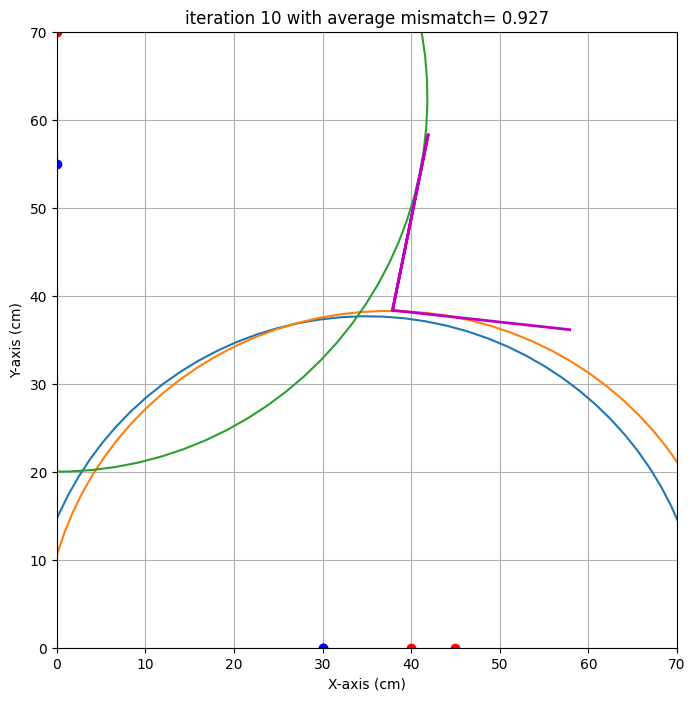

end iteration 10 with average mismatch= 0.927


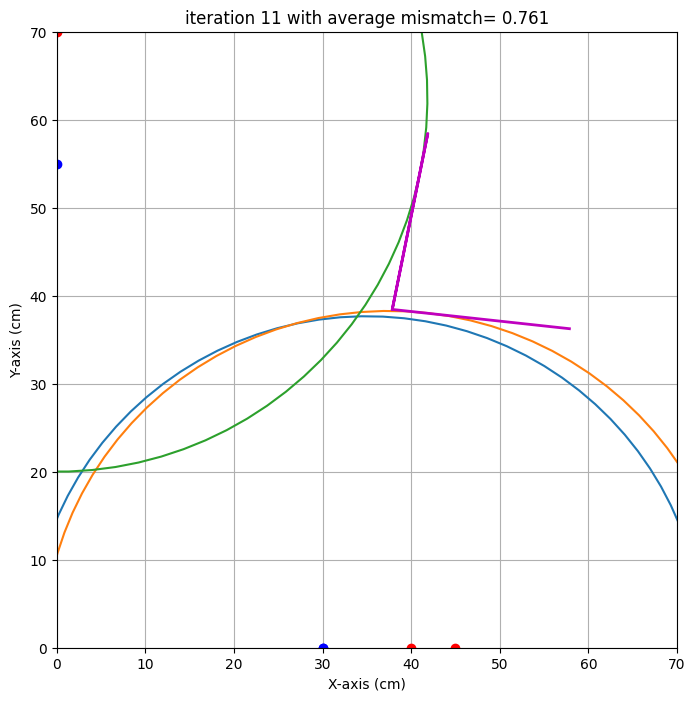

end iteration 11 with average mismatch= 0.761


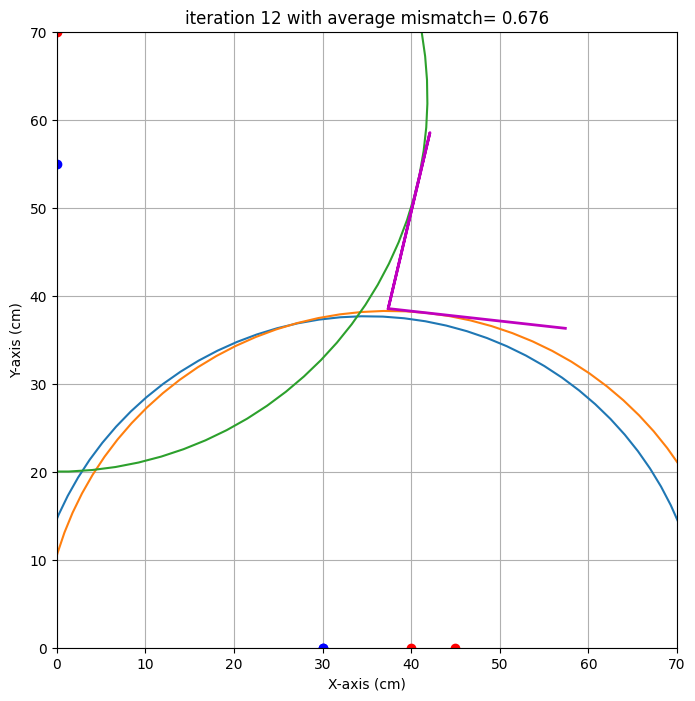

end iteration 12 with average mismatch= 0.676
end iteration 13 with average mismatch= 0.664
end iteration 14 with average mismatch= 0.662
end iteration 15 with average mismatch= 0.662
end iteration 16 with average mismatch= 0.662
end iteration 17 with average mismatch= 0.662
end iteration 18 with average mismatch= 0.662
end iteration 19 with average mismatch= 0.662
end iteration 20 with average mismatch= 0.662
end iteration 21 with average mismatch= 0.662
end iteration 22 with average mismatch= 0.662
end iteration 23 with average mismatch= 0.662
end iteration 24 with average mismatch= 0.662
end iteration 25 with average mismatch= 0.662
end iteration 26 with average mismatch= 0.662
end iteration 27 with average mismatch= 0.662
end iteration 28 with average mismatch= 0.662
end iteration 29 with average mismatch= 0.662
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.662
#################

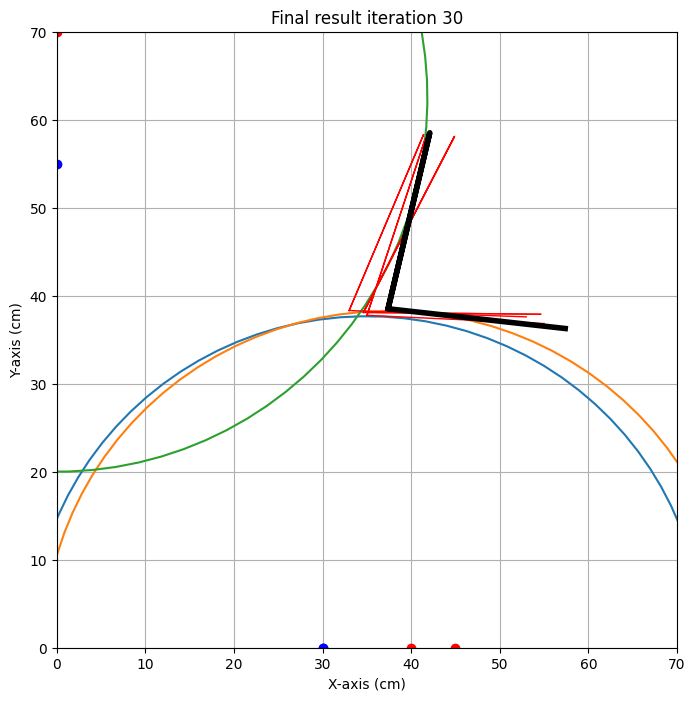

{'alpha': np.float64(-6.4003576810483365), 'alpha_eps': np.float64(5.800553488213967), 'beta': np.float64(13.247977678296063), 'beta_eps': np.float64(13.948073832218817), 'x0': np.float64(37.388805816338554), 'x0_eps': np.float64(4.396852069866775), 'y0': np.float64(38.51818680561632), 'y0_eps': np.float64(0.7461744958013412)}


In [32]:
# Hier runnen we het imaging algoritme:
resultaat = dict()
  
for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [33]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Isa 
x0 target is : 35.0. Gevonden waarde: 36.8 cm met een standaardafwijking van 3.6 cm 
y0 target is : 43.5. Gevonden waarde: 38.4 cm met een standaardafwijking van 0.8 cm 
alpha target is : 3.0. Gevonden waarde: -4.2 graden met een standaardafwijking van 4.2 graad 
beta target is : 26.0. Gevonden waarde: 15.3 graden met een standaardafwijking van 11.2 graad 

Thijs 
x0 target is : 35.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 1.3 cm 
y0 target is : 43.5. Gevonden waarde: 44.2 cm met een standaardafwijking van 1.6 cm 
alpha target is : 3.0. Gevonden waarde: -6.4 graden met een standaardafwijking van 15.0 graad 
beta target is : 26.0. Gevonden waarde: 6.4 graden met een standaardafwijking van 5.8 graad 

Arjun 
x0 target is : 35.0. Gevonden waarde: 37.4 cm met een standaardafwijking van 4.4 cm 
y0 target is : 43.5. Gevonden waarde: 38.5 cm met een standaardafwijking van 0.7 cm 
alpha target is : 3.0. Gevonden waarde: -6.4 graden met een standaardafwijking van 5.8 graad

## Opdracht 8: Iteratie2. 16:20.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie1.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 2 meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  65   0  78.3
1  50   0  65   0  79.4
2   0  47   0  67  74.9
3   0  42   0  67  81.1


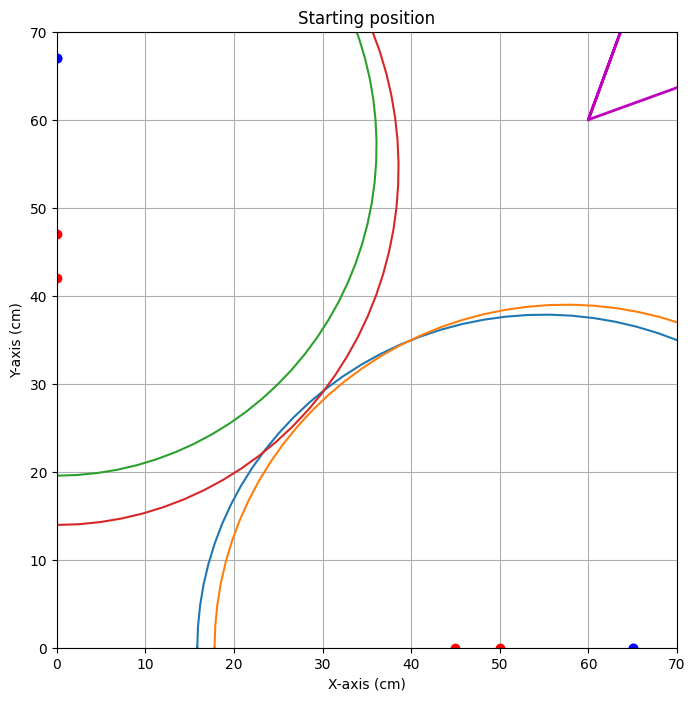


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.184


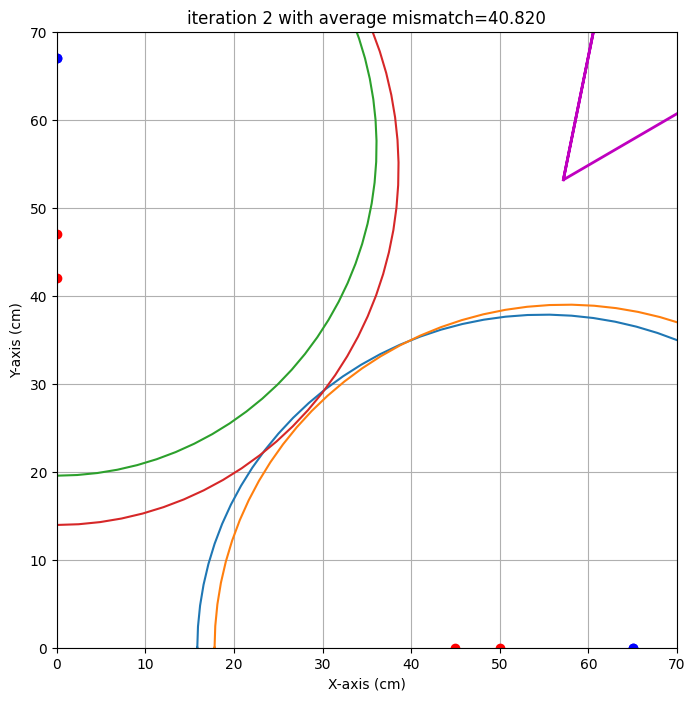

end iteration 2 with average mismatch=40.820


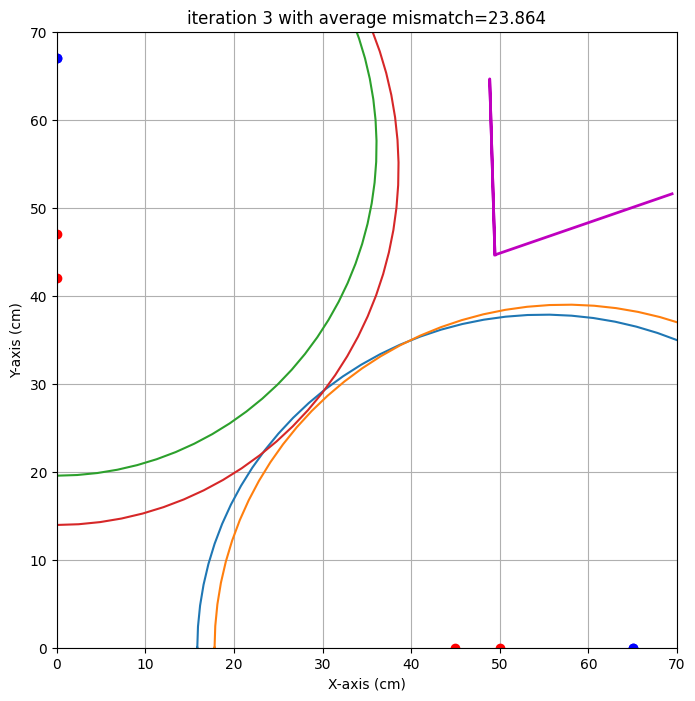

end iteration 3 with average mismatch=23.864


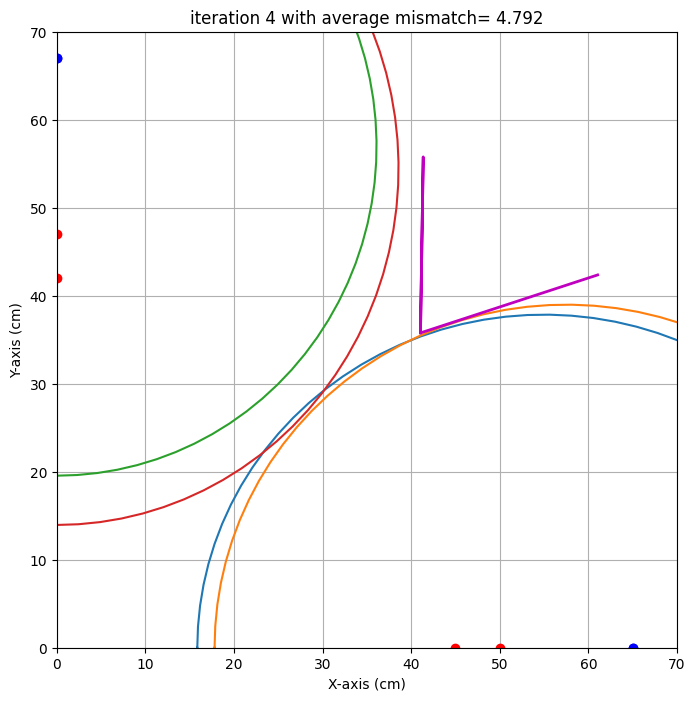

end iteration 4 with average mismatch= 4.792


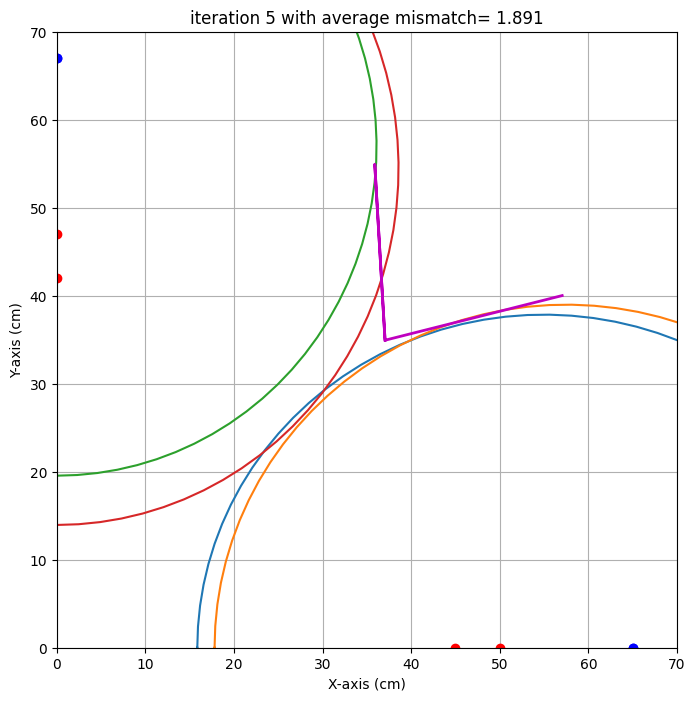

end iteration 5 with average mismatch= 1.891
end iteration 6 with average mismatch= 1.743
end iteration 7 with average mismatch= 1.743
end iteration 8 with average mismatch= 1.743
end iteration 9 with average mismatch= 1.743
end iteration 10 with average mismatch= 1.743
end iteration 11 with average mismatch= 1.743
end iteration 12 with average mismatch= 1.704


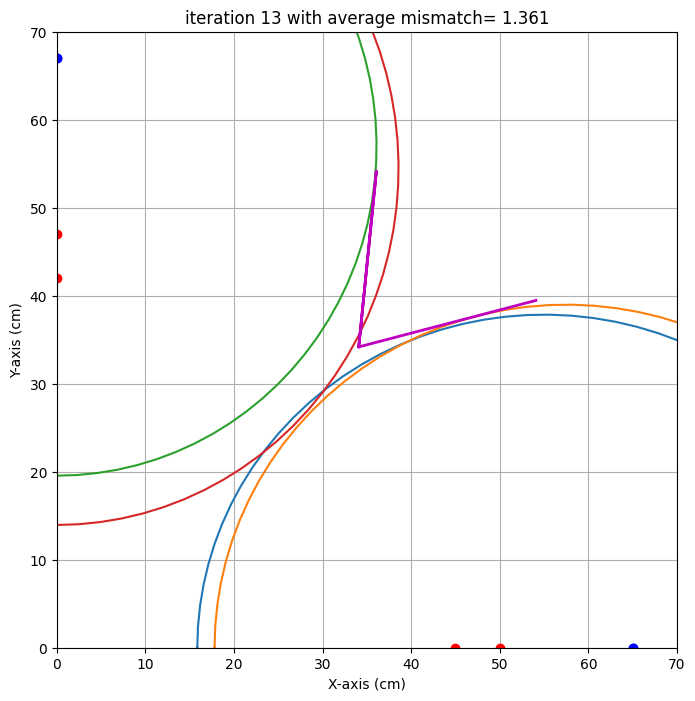

end iteration 13 with average mismatch= 1.361
end iteration 14 with average mismatch= 1.361
end iteration 15 with average mismatch= 1.361
end iteration 16 with average mismatch= 1.361
end iteration 17 with average mismatch= 1.361
end iteration 18 with average mismatch= 1.361
end iteration 19 with average mismatch= 1.361
end iteration 20 with average mismatch= 1.361
end iteration 21 with average mismatch= 1.336
end iteration 22 with average mismatch= 1.335
end iteration 23 with average mismatch= 1.335
end iteration 24 with average mismatch= 1.335
end iteration 25 with average mismatch= 1.335
end iteration 26 with average mismatch= 1.335
end iteration 27 with average mismatch= 1.335
end iteration 28 with average mismatch= 1.335
end iteration 29 with average mismatch= 1.335
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


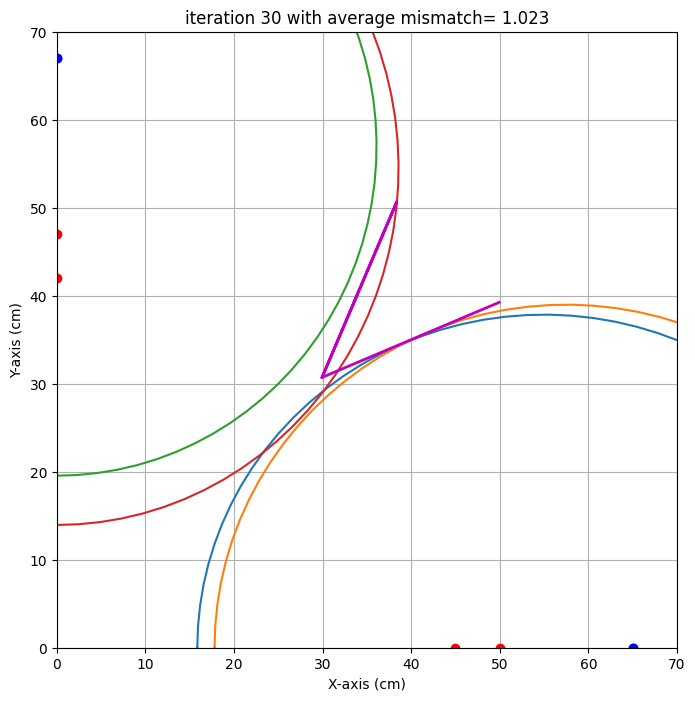

end iteration 30 with average mismatch= 1.023
###############################################################################
end of iteration  30
Best alpha=  23.10 with uncertainty=  12.72
Best beta =  22.93 with uncertainty=   6.36
Best x0   =  29.93 with uncertainty=   2.75
Best y0   =  30.71 with uncertainty=   3.89
###############################################################################


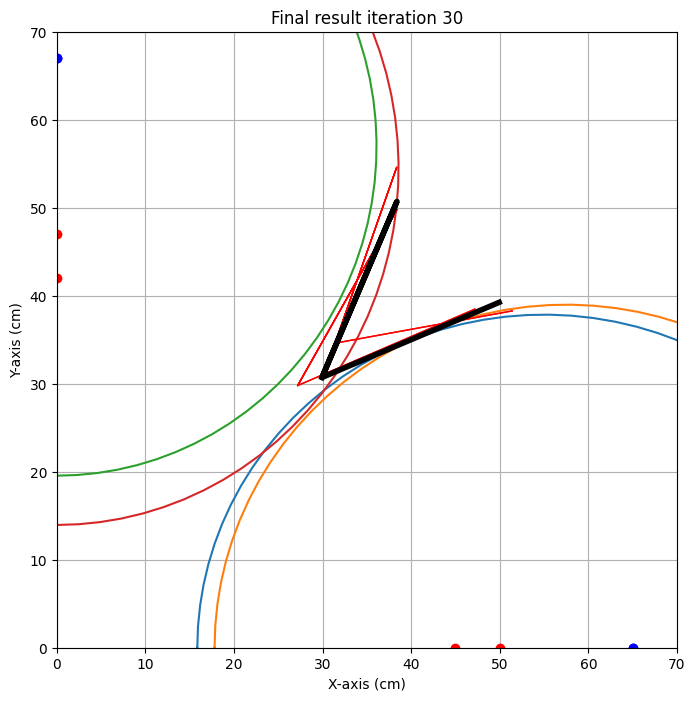

{'alpha': np.float64(23.10163474145524), 'alpha_eps': np.float64(12.716625125358092), 'beta': np.float64(22.930157271503667), 'beta_eps': np.float64(6.359135604102228), 'x0': np.float64(29.92986866477578), 'x0_eps': np.float64(2.7459458020944965), 'y0': np.float64(30.71387333564577), 'y0_eps': np.float64(3.894361592021813)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  45   0  65   0  115.4
1  50   0  65   0  116.0
2   0  65   0  85   69.0
3   0  60   0  85   68.0


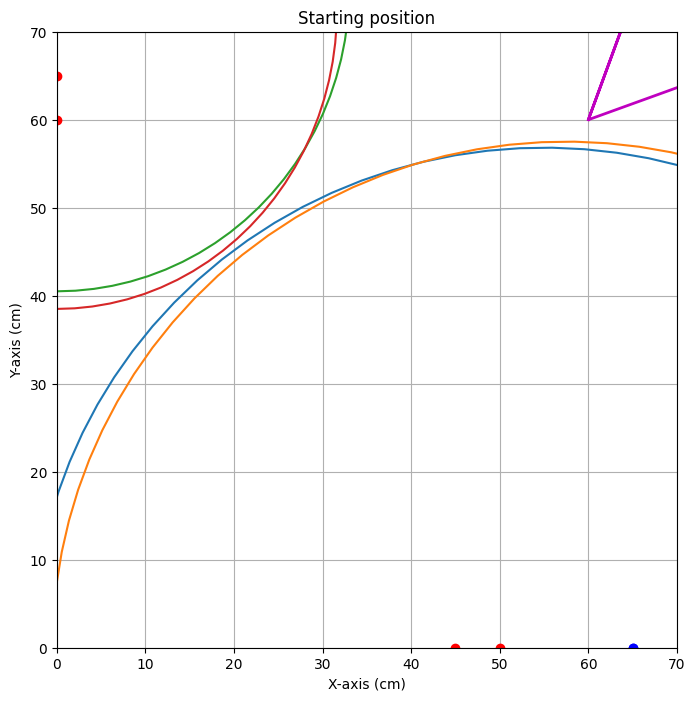


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=35.519


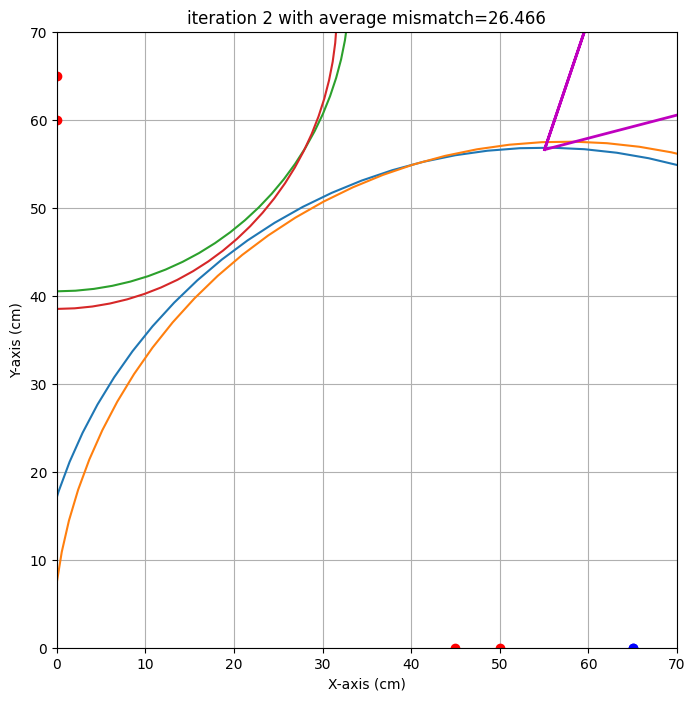

end iteration 2 with average mismatch=26.466


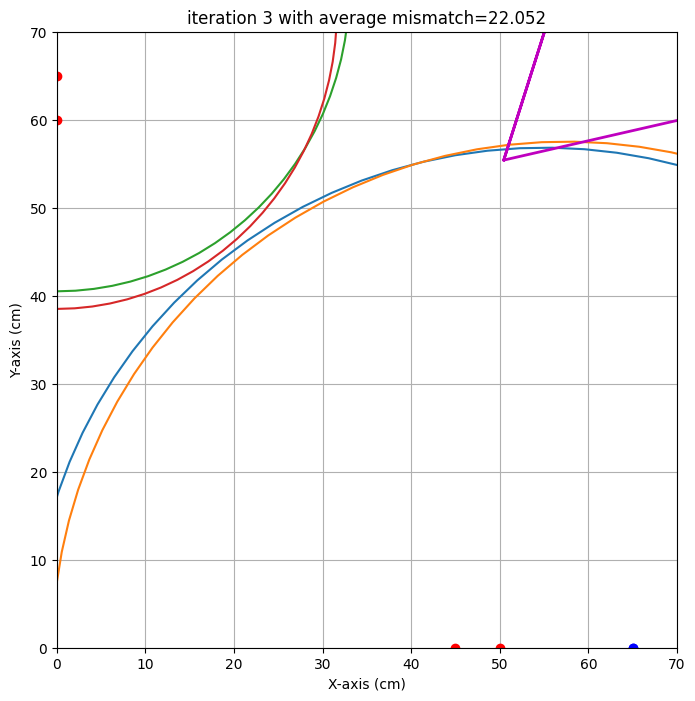

end iteration 3 with average mismatch=22.052


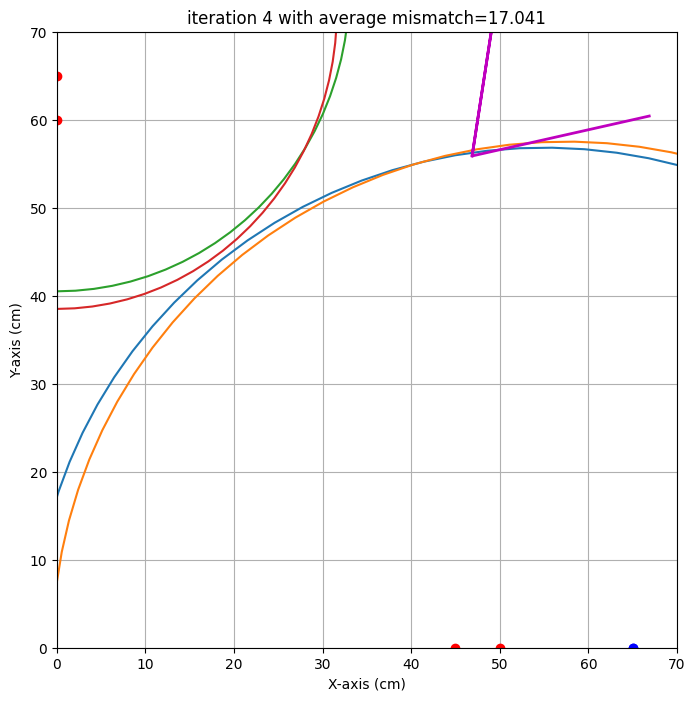

end iteration 4 with average mismatch=17.041


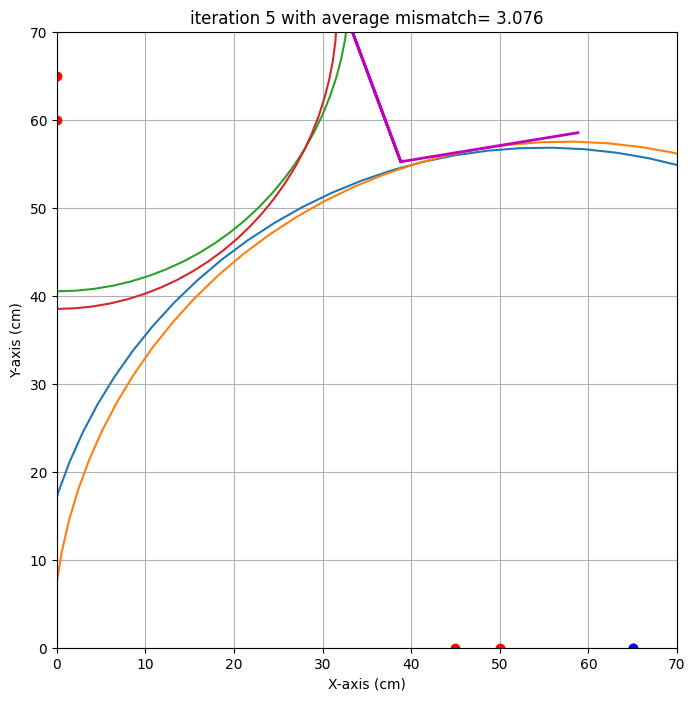

end iteration 5 with average mismatch= 3.076


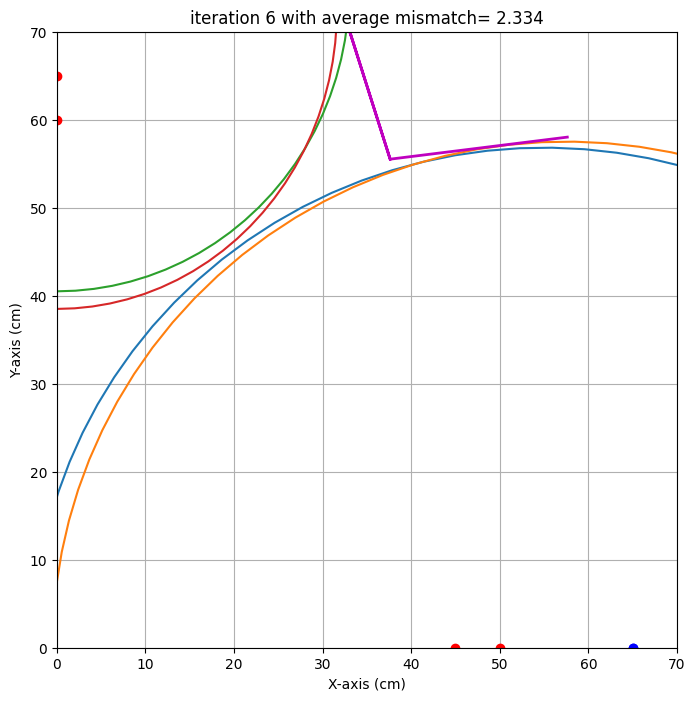

end iteration 6 with average mismatch= 2.334


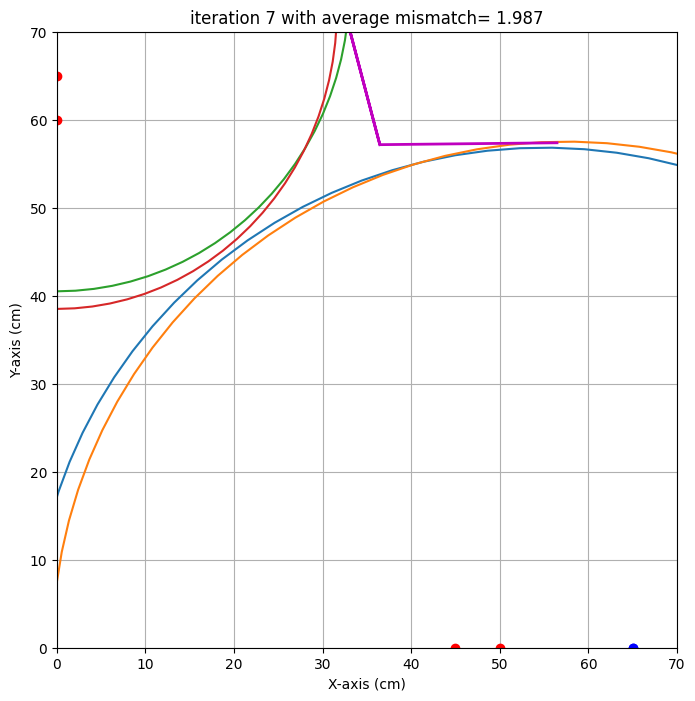

end iteration 7 with average mismatch= 1.987
end iteration 8 with average mismatch= 1.987
end iteration 9 with average mismatch= 1.916
end iteration 10 with average mismatch= 1.916
end iteration 11 with average mismatch= 1.789
end iteration 12 with average mismatch= 1.789
end iteration 13 with average mismatch= 1.747


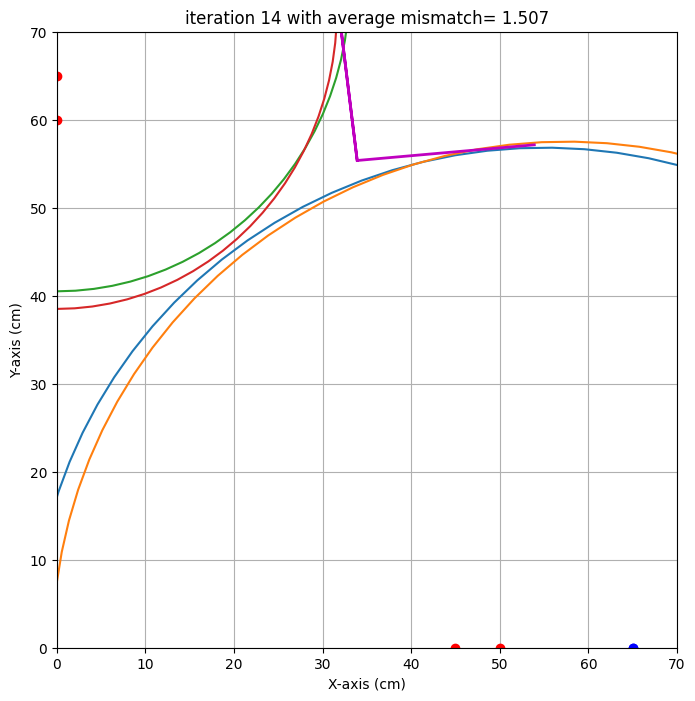

end iteration 14 with average mismatch= 1.507


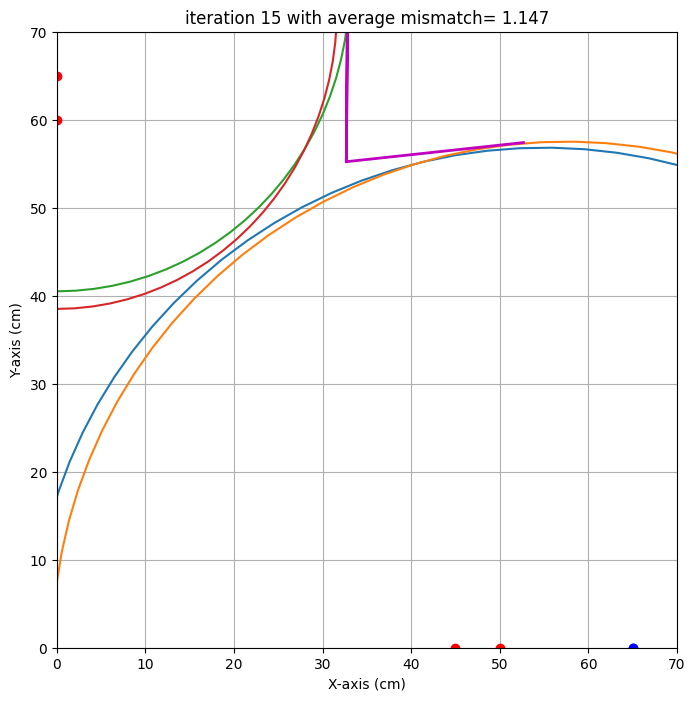

end iteration 15 with average mismatch= 1.147


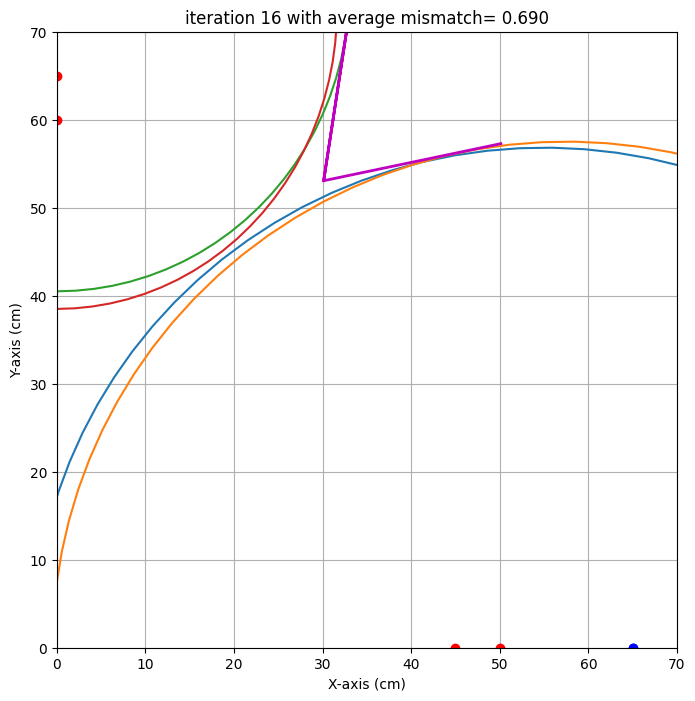

end iteration 16 with average mismatch= 0.690
end iteration 17 with average mismatch= 0.638
end iteration 18 with average mismatch= 0.632
end iteration 19 with average mismatch= 0.614


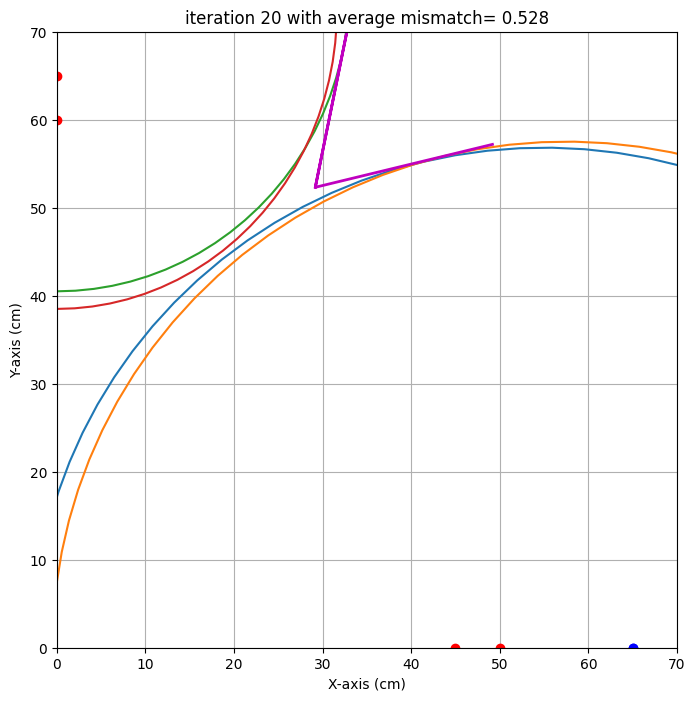

end iteration 20 with average mismatch= 0.528
end iteration 21 with average mismatch= 0.484
end iteration 22 with average mismatch= 0.458
end iteration 23 with average mismatch= 0.446
end iteration 24 with average mismatch= 0.442
end iteration 25 with average mismatch= 0.442
end iteration 26 with average mismatch= 0.442
end iteration 27 with average mismatch= 0.442
end iteration 28 with average mismatch= 0.442
end iteration 29 with average mismatch= 0.442
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


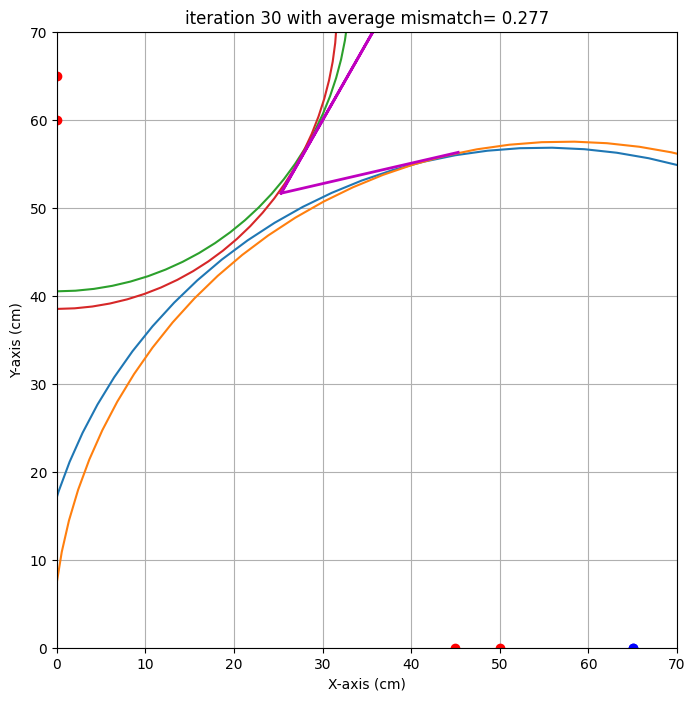

end iteration 30 with average mismatch= 0.277
###############################################################################
end of iteration  30
Best alpha=  13.07 with uncertainty=  14.65
Best beta =  29.49 with uncertainty=   5.04
Best x0   =  25.30 with uncertainty=   0.90
Best y0   =  51.65 with uncertainty=   3.38
###############################################################################


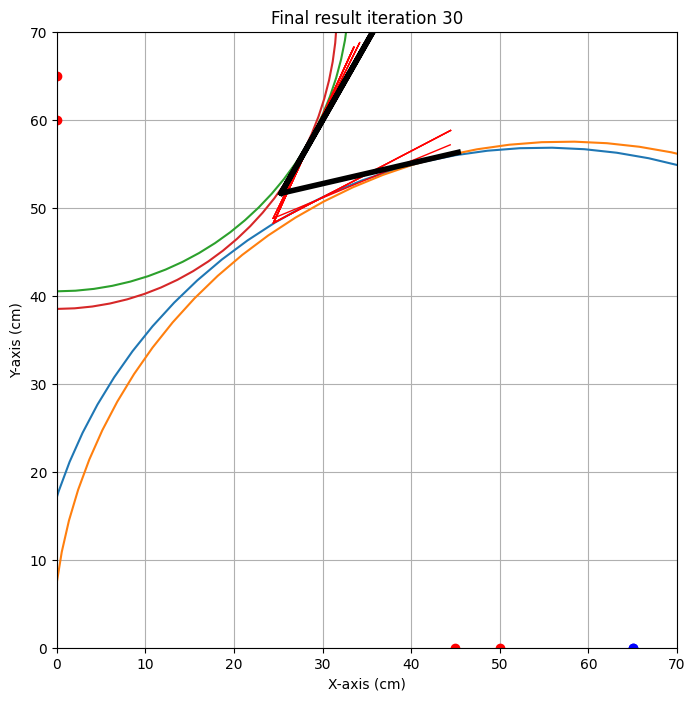

{'alpha': np.float64(13.074780097706682), 'alpha_eps': np.float64(14.653017661363531), 'beta': np.float64(29.487731549562955), 'beta_eps': np.float64(5.035396089263646), 'x0': np.float64(25.30368831853161), 'x0_eps': np.float64(0.9001491885155772), 'y0': np.float64(51.64638114259373), 'y0_eps': np.float64(3.3801197652126405)}
locatie 1 
x0 target is : 30.0. Gevonden waarde: 29.9 cm met een standaardafwijking van 2.7 cm 
y0 target is : 36.5. Gevonden waarde: 30.7 cm met een standaardafwijking van 3.9 cm 
alpha target is : 3.0. Gevonden waarde: 23.1 graden met een standaardafwijking van 12.7 graad 
beta target is : 22.0. Gevonden waarde: 22.9 graden met een standaardafwijking van 6.4 graad 

locatie 2 
x0 target is : 23.0. Gevonden waarde: 25.3 cm met een standaardafwijking van 0.9 cm 
y0 target is : 50.0. Gevonden waarde: 51.6 cm met een standaardafwijking van 3.4 cm 
alpha target is : 18.0. Gevonden waarde: 13.1 graden met een standaardafwijking van 14.7 graad 
beta target is : 35.0. G

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':30,
                    'y0':36.5,
                    'alpha' : 3,
                    'beta' : 22},
           'locatie 2':{'x0':23,
                    'y0':50,
                    'alpha' : 18,
                    'beta' : 35}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,65,0,78.3],
    [50,0,65,0,79.4],
    #[0,47,0,27,0]
    [0,47,0,67,74.90],
    [0,42,0,67,81.1]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,65,0,115.4],
    [50,0,65,0,116],
    [0,65,0,85,69],
    [0,60,0,85,68]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  25   0  79.7
1  40   0  25   0  79.2
2  35   0  25   0  79.7
3   0  47   0  67  66.7
4   0  52   0  67  67.2
5   0  57   0  67  67.0


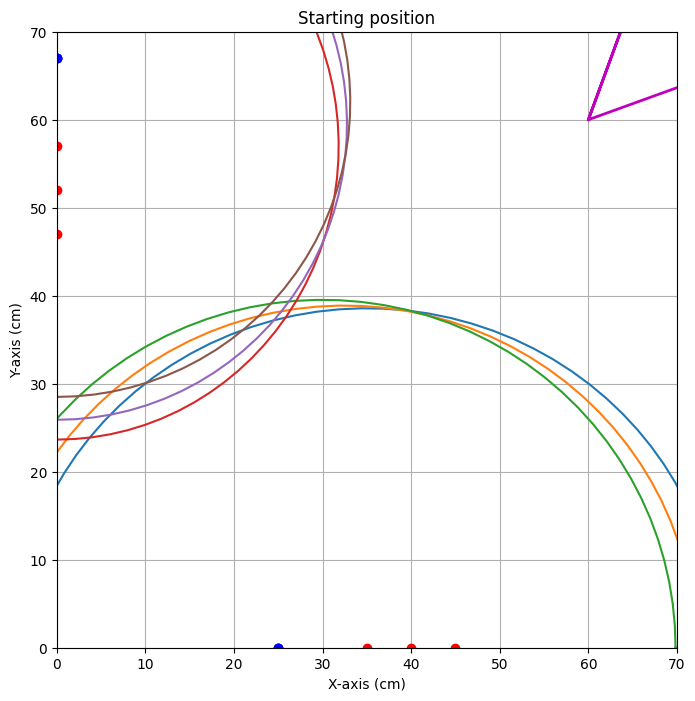


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=58.949


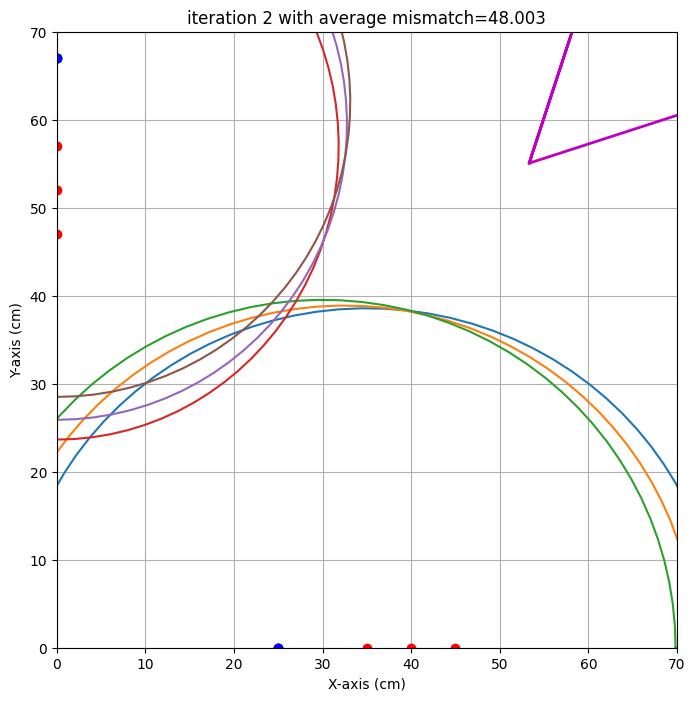

end iteration 2 with average mismatch=48.003


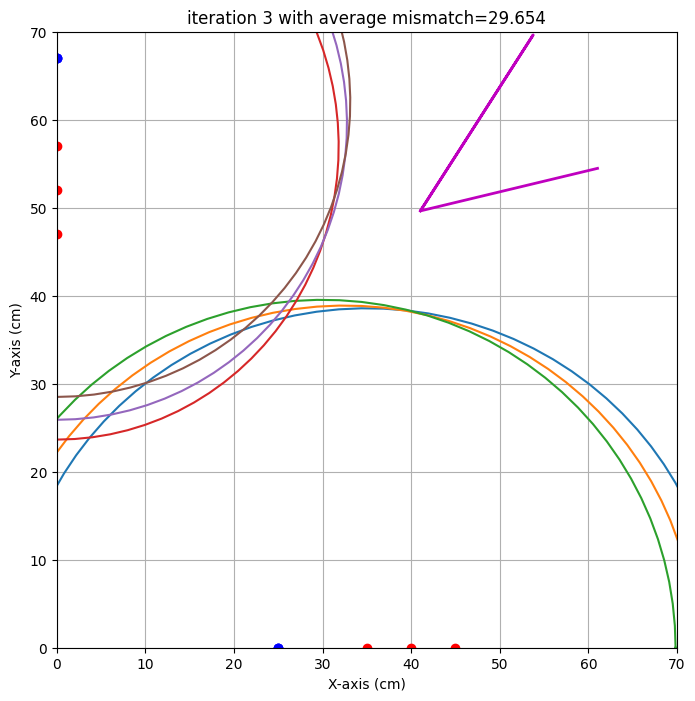

end iteration 3 with average mismatch=29.654


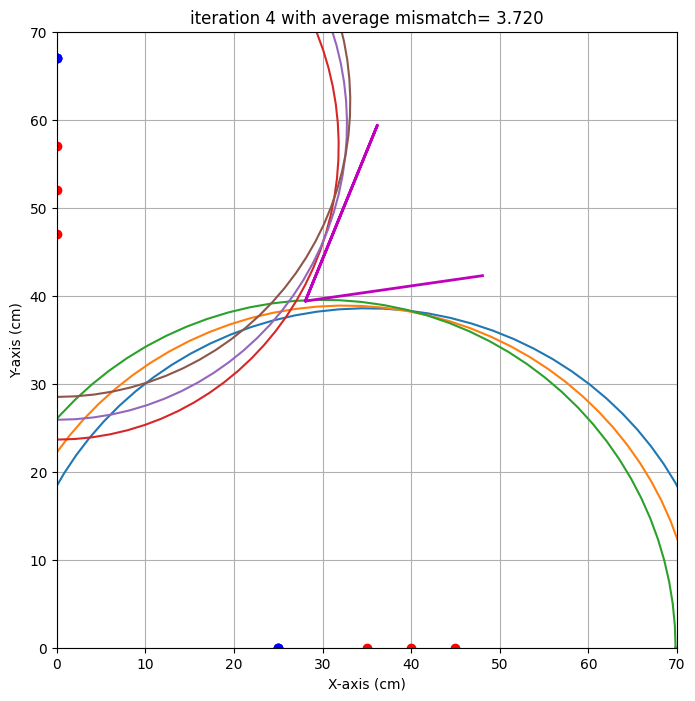

end iteration 4 with average mismatch= 3.720


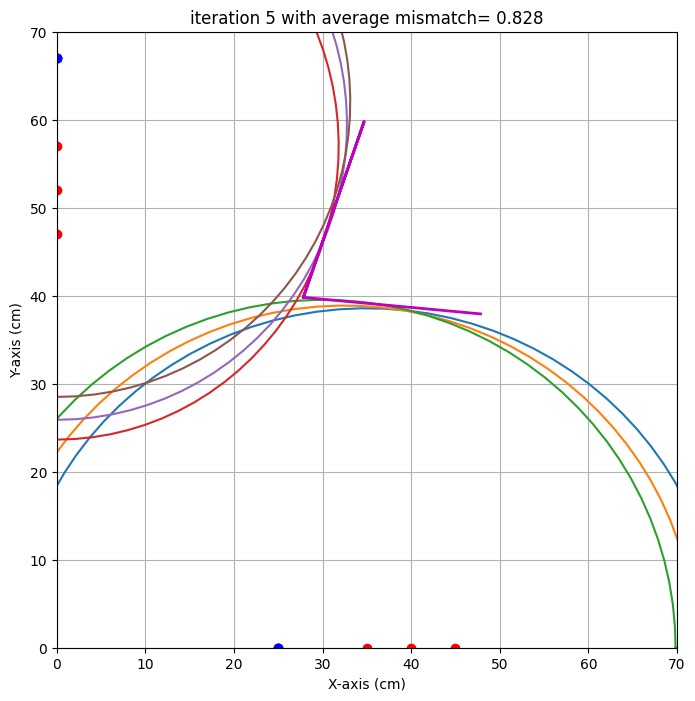

end iteration 5 with average mismatch= 0.828


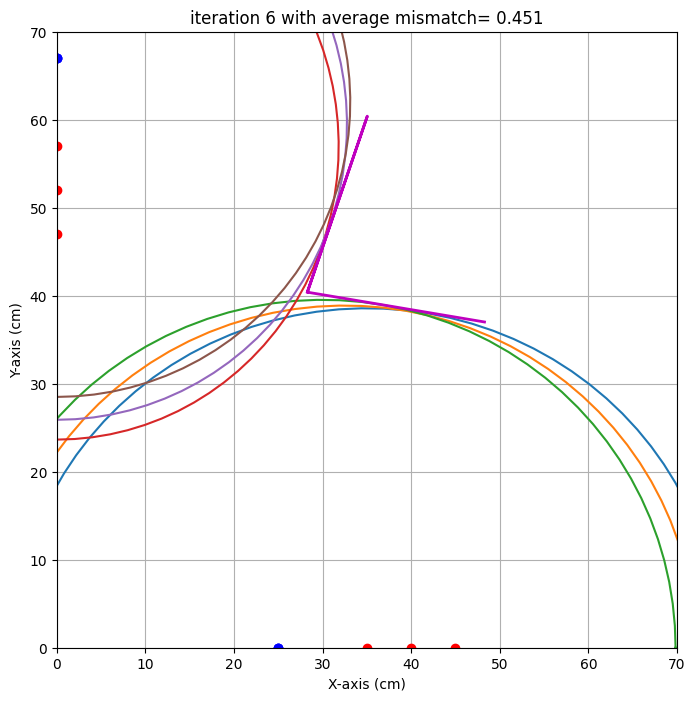

end iteration 6 with average mismatch= 0.451
end iteration 7 with average mismatch= 0.429
end iteration 8 with average mismatch= 0.417
end iteration 9 with average mismatch= 0.405
end iteration 10 with average mismatch= 0.403
end iteration 11 with average mismatch= 0.403
end iteration 12 with average mismatch= 0.393
end iteration 13 with average mismatch= 0.363
end iteration 14 with average mismatch= 0.333
end iteration 15 with average mismatch= 0.333
end iteration 16 with average mismatch= 0.332
end iteration 17 with average mismatch= 0.332
end iteration 18 with average mismatch= 0.332
end iteration 19 with average mismatch= 0.332
end iteration 20 with average mismatch= 0.332
end iteration 21 with average mismatch= 0.332
end iteration 22 with average mismatch= 0.332
end iteration 23 with average mismatch= 0.332
end iteration 24 with average mismatch= 0.320
end iteration 25 with average mismatch= 0.318
end iteration 26 with average mismatch= 0.318
end iteration 27 with average mismatch

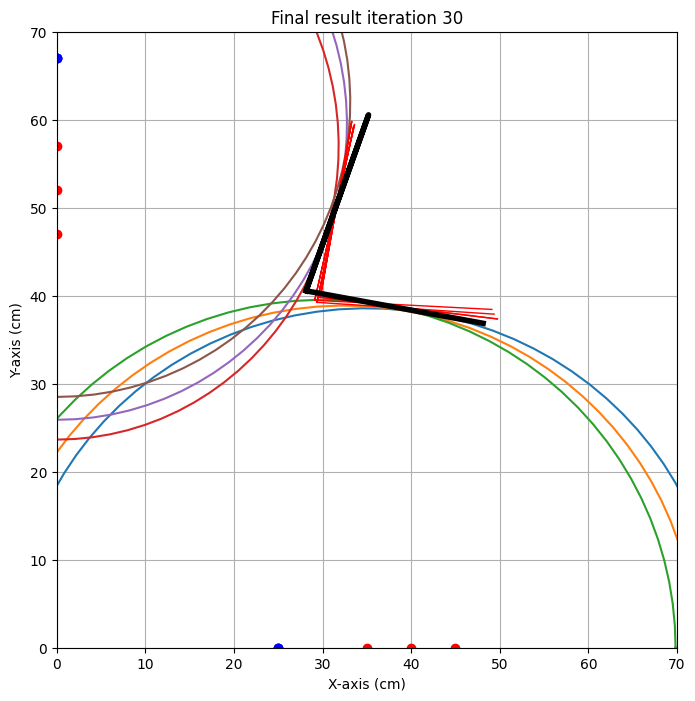

{'alpha': np.float64(-10.453738937047135), 'alpha_eps': np.float64(7.479599044791851), 'beta': np.float64(19.439540951933697), 'beta_eps': np.float64(9.357491228850865), 'x0': np.float64(28.12517539289301), 'x0_eps': np.float64(1.603969894023166), 'y0': np.float64(40.55408117213579), 'y0_eps': np.float64(1.3070933054240044)}
test locatie 
x0 target is : 28.5. Gevonden waarde: 28.1 cm met een standaardafwijking van 1.6 cm 
y0 target is : 41.3. Gevonden waarde: 40.6 cm met een standaardafwijking van 1.3 cm 
alpha target is : -14.0. Gevonden waarde: -10.5 graden met een standaardafwijking van 7.5 graad 
beta target is : 15.0. Gevonden waarde: 19.4 graden met een standaardafwijking van 9.4 graad 



In [47]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  28.5,
                    'y0':  41.3,
                    'alpha' :  -14,
                    'beta' :  15
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    #[45,0,65,0,0]
                    [45,0,25,0,79.7],
                    [40,0,25,0,79.2],
                    [35,0,25,0,79.7],
                    #[0,47,0,27,0]
                    [0,47,0,67,66.7],
                    [0,52,0,67,67.2],
                    [0,57,0,67,67]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](Schema3.jpeg "Title")

Het principe is hetzelfde gebleven maar het is meer gestroomlijnd. We beginnen met X = 45 omdat daar altijd iets gedetecteerd wordt en dan testen we aan beide kanten of er een meting is omdat liggend aan hoe het papier is gekanteld er maar via 1 kant gemeten kan worden. dan wordt de 2e meting op de x as gemaakt door de bron 5 cm op zij te schuiven en als die dan geen meting maakt 5cm de andere kant op te schuiven. Dan gebruiken we dat zelfde principe op de y as maar dan kijken we op 2 locaties met de bron gebaseerd op de totale y as gedeelt door 3. Voor de tweede meting op de y as doen we weer hetzelfde. 
Figuur: ![Alt](Iteratie1.jpeg "Title")

Wij hebben meerdere stappen genomen voor een beter resultaat. Afstand tussen sensoren is ook gevarieerd om scherpere hoeken beter te meten, dit zorgt voor minder foutieve resultaten. Handmatig de sensor hoek aangepast om te helpen dit geeft een hogere range waardoor wij minder metingen hoeven te maken, dus is het efficiënter werken.
Figuur: ![Alt](Iteratie2.jpeg "Title")
